### S1: Spot–Futures Basis Capture (carry / convergence)

**Idea:** If futures trade above spot, run **long spot / short futures** and capture convergence into expiry.

**Signal (entry):**
- Annualised basis for BTC2, BTC3:
$$
\text{ann\_basis}_t=\frac{F_t-S_t}{S_t}\cdot\frac{365}{\text{DTE}_t}
$$
- Enter if:
  - DTE in **60–120** days  
  - ann. basis **> 5% p.a.**  
  - choose the higher ann. basis (BTC2 vs BTC3)

**Position (fully funded, 1:1 notional):**
- Long spot:
$$
N=\frac{\text{equity}}{S_t}
$$
- Short futures: same BTC notional \(N\)

**Daily MTM PnL (in trade):**
$$
\Delta PnL_t = N(\Delta S_t-\Delta F_t)
$$

**Exit (forced close):**
- Synthetic expiry set at entry:
$$
T^*=t_{\text{entry}}+\text{DTE}_{\text{entry}}
$$
- Close **`days_before_expiry_close`** before \(T^*\) (default **5** days)

**Stitching / roll treatment (important):**
- While holding, the futures leg is **marked** using the listed contract (btc1..btc4) whose DTE is **closest** to remaining days to \(T^*\).
- The marking contract can switch over time; **no roll trade is booked** at these switches (marking convention only).
- Trading costs are applied only at **entry and exit** (two legs each time).

**Transaction costs:**
- `tc_rate = 0.0005` per leg, charged on traded notional:
  - open: `tc_rate * (spot_notional + futures_notional)`
  - close: same

**IS/OOS split:**
- IS: 2018-01-01 to 2022-12-31  
- OOS: 2023-01-01 to 2025-12-31  


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import calendar
from datetime import date, timedelta

plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 4)

# IS / OOS split (BTC futures start in 2018)

IS_START   = pd.Timestamp("2018-01-01")
SPLIT_DATE = pd.Timestamp("2023-01-01")   # OOS starts here
OOS_END    = pd.Timestamp("2025-12-31")

IS_END = SPLIT_DATE - pd.Timedelta(days=1)



# Load GOLD / SILVER futures + spot from Basis Data.xlsx


In [2]:


xlsx_path = "Basis Data.xlsx"

# Sheets and tickers needed
SHEET_CONFIG = {
    "GC": ["XAU", "GC1", "GC2", "GC3", "GC4", "GC7"],  
    "SI": ["XAG", "SI1", "SI2", "SI3", "SI4", "SI7"],  
}

def extract_pair_as_series(df: pd.DataFrame, value_col_name: str, new_value_name: str | None = None) -> pd.Series:
    """
    Uses the column immediately to the LEFT as the date column – matching your Excel structure
    where each price has its own date column.

    df: DataFrame from one sheet
    value_col_name: e.g. "GC1", "XAU"
    new_value_name: column name in the output (defaults to value_col_name)
    """
    if new_value_name is None:
        new_value_name = value_col_name

    col_idx  = df.columns.get_loc(value_col_name)
    date_col = df.columns[col_idx - 1]

    sub = df[[date_col, value_col_name]].copy()
    sub = sub.dropna()
    sub = sub.rename(columns={date_col: "date", value_col_name: new_value_name})
    sub["date"] = pd.to_datetime(sub["date"])
    sub = sub.set_index("date").sort_index()
    sub = sub[~sub.index.duplicated(keep="last")]
    return sub

def build_panel_for_sheet(sheet_name: str, tickers: list[str]) -> pd.DataFrame:
    df_raw = pd.read_excel(xlsx_path, sheet_name=sheet_name)

    series_list = []
    for t in tickers:
        s = extract_pair_as_series(df_raw, t, new_value_name=t)
        series_list.append(s)

    panel = pd.concat(series_list, axis=1).sort_index()
    panel = panel[~panel.index.duplicated(keep="last")]
    panel = panel.loc[:, ~panel.columns.duplicated(keep="first")]
    return panel

panels = {}
for sheet, tickers in SHEET_CONFIG.items():
    print(f"Building panel for {sheet} …")
    panels[sheet] = build_panel_for_sheet(sheet, tickers)

gc_panel = panels["GC"]
si_panel = panels["SI"]

gc_panel = gc_panel.sort_index().loc[IS_START:OOS_END]
si_panel = si_panel.sort_index().loc[IS_START:OOS_END]

print("GC columns:", gc_panel.columns.tolist())
print("SI columns:", si_panel.columns.tolist())


Building panel for GC …
Building panel for SI …
GC columns: ['XAU', 'GC1', 'GC2', 'GC3', 'GC4', 'GC7']
SI columns: ['XAG', 'SI1', 'SI2', 'SI3', 'SI4', 'SI7']


# Loading in the actual futures

In [3]:

btc_xlsx_path = "IBIT.xlsx"
btc_raw = pd.read_excel(btc_xlsx_path, sheet_name="BTC")

def extract_series_btc(df: pd.DataFrame, date_col: str, value_col: str, value_name: str) -> pd.Series:
    sub = df[[date_col, value_col]].dropna()
    sub = sub.rename(columns={date_col: "date", value_col: value_name})
    sub["date"] = pd.to_datetime(sub["date"])
    sub = sub.set_index("date").sort_index()
    sub = sub[~sub.index.duplicated(keep="last")]
    return sub

btc_series_list = []

# Spot (note: BTC spot is XBT)
btc_series_list.append(
    extract_series_btc(btc_raw, "Date-XBT", "XBT-USD", "xbt_usd")
)

# First 4 BTC futures (btc1..btc4)
for k in range(1, 5):
    btc_series_list.append(
        extract_series_btc(
            btc_raw,
            f"Date-BTC{k}",
            f"BTC{k}",
            f"btc{k}",
        )
    )

df_btc = pd.concat(btc_series_list, axis=1).sort_index()
df_btc = df_btc.sort_index().loc[IS_START:OOS_END]
df_btc = df_btc.loc[:, ~df_btc.columns.duplicated(keep="first")]

print("BTC columns:", df_btc.columns.tolist())


BTC columns: ['xbt_usd', 'btc1', 'btc2', 'btc3', 'btc4']


# Contract speciiffaitions 

# Sources 
# - CME BTC futures intro: https://www.cmegroup.com/education/courses/introduction-to-bitcoin/what-are-bitcoin-futures.html
# - CME Gold specs:        https://www.cmegroup.com/markets/metals/precious/gold.contractSpecs.html
# - CME Silver specs:      https://www.cmegroup.com/markets/metals/precious/silver.contractSpecs.html

In [4]:

CONTRACT_SPECS = {
    "BTC": {
        "contract_size": 5.0,     # 5 bitcoin per CME BTC futures contract
        "calendar_type": "monthly_last_friday",
    },
    "GC": {
        "contract_size": 100.0,   # 100 troy ounces per COMEX Gold futures contract
        "calendar_type": "bi_monthly_third_last_bday",
        "months": [2, 4, 6, 8, 10, 12],
    },
    "SI": { # note: intiially in the diagram for PPT and report, we used different 3 month futures, but for ease of data handling here we use monthly futures -
        "contract_size": 5000.0,  # 5,000 troy ounces per COMEX Silver futures contract
        "calendar_type": "monthly_third_last_bday",
    },
}

def third_last_business_day(year: int, month: int) -> date:
    """
    Return the third-last business day (Mon–Fri) of a given month.
    Holidays ignored (intentionally simple).
    """
    last_day = calendar.monthrange(year, month)[1]
    all_days = [date(year, month, d) for d in range(1, last_day + 1)]
    biz_days = [d for d in all_days if d.weekday() < 5]
    return biz_days[-3]

def last_friday(year: int, month: int) -> date:
    """Return the last Friday of a given month."""
    last_day = calendar.monthrange(year, month)[1]
    d = date(year, month, last_day)
    while d.weekday() != 4:  
        d -= timedelta(days=1)
    return d

def generate_gold_contract_months(trade_date: date, n_contracts: int = 7):
    """
    GC: delivery months Feb/Apr/Jun/Aug/Oct/Dec; expiry = third last business day of delivery month.
    Returns list of (year, month, expiry_date) for next n_contracts.
    """
    allowed_months = CONTRACT_SPECS["GC"]["months"]
    result = []

    y, m = trade_date.year, trade_date.month
    while len(result) < n_contracts:
        if m in allowed_months:
            exp = third_last_business_day(y, m)
            if exp >= trade_date or len(result) > 0:
                result.append((y, m, exp))
        m += 1
        if m > 12:
            m = 1
            y += 1

    return result

def generate_silver_contract_months(trade_date: date, n_contracts: int = 7):
    """
    SI: treat as monthly; expiry = third last business day of delivery month.
    """
    result = []
    y, m = trade_date.year, trade_date.month

    while len(result) < n_contracts:
        exp = third_last_business_day(y, m)
        if exp >= trade_date or len(result) > 0:
            result.append((y, m, exp))
        m += 1
        if m > 12:
            m = 1
            y += 1

    return result

def generate_btc_contract_months(trade_date: date, n_contracts: int = 4):
    """
    BTC: monthly; expiry = last Friday of contract month.
    """
    result = []
    y, m = trade_date.year, trade_date.month

    this_month_exp = last_friday(y, m)
    if this_month_exp >= trade_date:
        current_y, current_m = y, m
    else:
        current_y, current_m = y, m + 1
        if current_m > 12:
            current_m = 1
            current_y += 1

    y, m = current_y, current_m
    while len(result) < n_contracts:
        exp = last_friday(y, m)
        result.append((y, m, exp))
        m += 1
        if m > 12:
            m = 1
            y += 1

    return result

def build_gc_dte_calendar(gc_panel: pd.DataFrame) -> pd.DataFrame:
    """
    For each date in gc_panel.index, compute DTE for GC1..GC7 using GC rules.
    """
    contracts = [f"GC{k}" for k in range(1, 8)]
    dte_df = pd.DataFrame(index=gc_panel.index, columns=[f"{c}_DTE" for c in contracts])

    for d in dte_df.index:
        trade_date = d.date()
        months = generate_gold_contract_months(trade_date, n_contracts=len(contracts))
        for c, (_, _, exp) in zip(contracts, months):
            dte_df.loc[d, f"{c}_DTE"] = (exp - trade_date).days

    return dte_df.astype(float)

def build_si_dte_calendar(si_panel: pd.DataFrame) -> pd.DataFrame:
    """
    For each date in si_panel.index, compute DTE for SI1..SI7 using SI rules.
    """
    contracts = [f"SI{k}" for k in range(1, 8)]
    dte_df = pd.DataFrame(index=si_panel.index, columns=[f"{c}_DTE" for c in contracts])

    for d in dte_df.index:
        trade_date = d.date()
        months = generate_silver_contract_months(trade_date, n_contracts=len(contracts))
        for c, (_, _, exp) in zip(contracts, months):
            dte_df.loc[d, f"{c}_DTE"] = (exp - trade_date).days

    return dte_df.astype(float)

def build_btc_dte_calendar(df_btc: pd.DataFrame) -> pd.DataFrame:
    """
    For each date in df_btc.index, compute DTE for btc1..btc4 using BTC rules.
    """
    contracts = [f"btc{k}" for k in range(1, 5)]
    dte_df = pd.DataFrame(index=df_btc.index, columns=[f"{c}_DTE" for c in contracts])

    for d in dte_df.index:
        trade_date = d.date()
        months = generate_btc_contract_months(trade_date, n_contracts=len(contracts))
        for c, (_, _, exp) in zip(contracts, months):
            dte_df.loc[d, f"{c}_DTE"] = (exp - trade_date).days

    return dte_df.astype(float)

# Build DTE panels
gc_dte  = build_gc_dte_calendar(gc_panel)
si_dte  = build_si_dte_calendar(si_panel)
btc_dte = build_btc_dte_calendar(df_btc)
btc_dte = btc_dte.sort_index().reindex(df_btc.index).loc[IS_START:OOS_END]
gc_dte = gc_dte.sort_index().reindex(gc_panel.index).loc[IS_START:OOS_END]
si_dte = si_dte.sort_index().reindex(si_panel.index).loc[IS_START:OOS_END]



print(gc_dte.head())
print(si_dte.head())
print(btc_dte.head())


            GC1_DTE  GC2_DTE  GC3_DTE  GC4_DTE  GC5_DTE  GC6_DTE  GC7_DTE
date                                                                     
2018-01-02     55.0    114.0    176.0    239.0    300.0    359.0    420.0
2018-01-03     54.0    113.0    175.0    238.0    299.0    358.0    419.0
2018-01-04     53.0    112.0    174.0    237.0    298.0    357.0    418.0
2018-01-05     52.0    111.0    173.0    236.0    297.0    356.0    417.0
2018-01-08     49.0    108.0    170.0    233.0    294.0    353.0    414.0
            SI1_DTE  SI2_DTE  SI3_DTE  SI4_DTE  SI5_DTE  SI6_DTE  SI7_DTE
date                                                                     
2018-01-02     27.0     55.0     85.0    114.0    147.0    176.0    206.0
2018-01-03     26.0     54.0     84.0    113.0    146.0    175.0    205.0
2018-01-04     25.0     53.0     83.0    112.0    145.0    174.0    204.0
2018-01-05     24.0     52.0     82.0    111.0    144.0    173.0    203.0
2018-01-08     21.0     49.0     79.0 

# ensuring the DTEs and other sanity checks


=== DTE sanity checks for Gold (GC) ===
Total negative DTE entries: 0

Summary statistics (days-to-expiry):
          count        mean        std    min    10%    50%    90%    max
GC1_DTE  2020.0   29.861386  17.545401    0.0    6.0   29.5   54.0   62.0
GC2_DTE  2020.0   90.774752  17.587994   57.0   66.0   91.0  114.1  124.0
GC3_DTE  2020.0  151.672772  17.573545  119.0  127.0  152.0  176.0  185.0
GC4_DTE  2020.0  212.550990  17.565553  179.0  188.9  212.0  237.0  244.0
GC5_DTE  2020.0  273.374257  17.552512  240.0  249.9  273.0  298.0  307.0
GC6_DTE  2020.0  334.183168  17.543976  301.0  309.9  335.0  358.0  365.0
GC7_DTE  2020.0  395.090594  17.537230  364.0  371.0  395.0  419.0  427.0
Pairs GC1_DTE -> GC2_DTE: 0 non-monotone rows
Pairs GC2_DTE -> GC3_DTE: 0 non-monotone rows
Pairs GC3_DTE -> GC4_DTE: 0 non-monotone rows
Pairs GC4_DTE -> GC5_DTE: 0 non-monotone rows
Pairs GC5_DTE -> GC6_DTE: 0 non-monotone rows
Pairs GC6_DTE -> GC7_DTE: 0 non-monotone rows
Total monotonicity viol

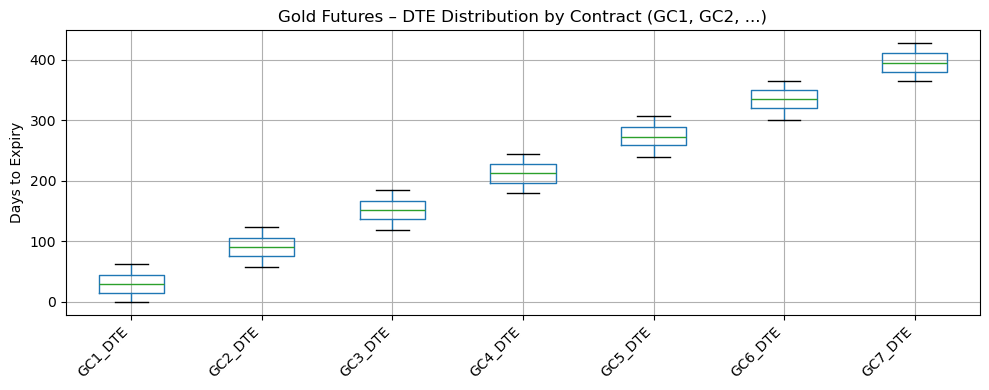

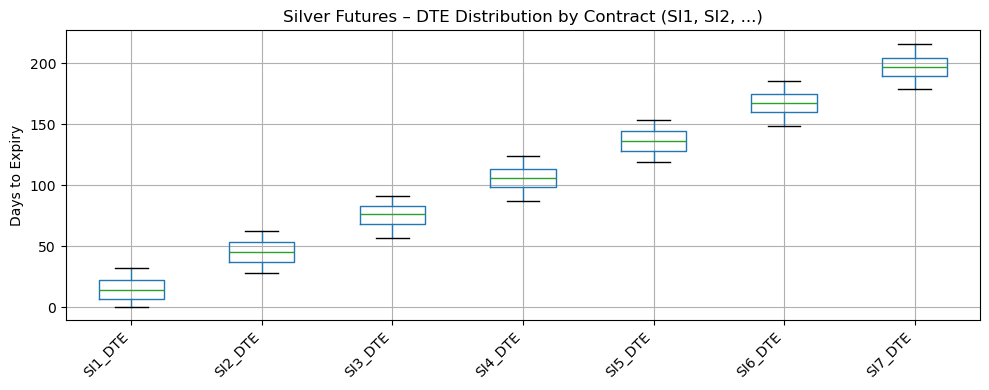

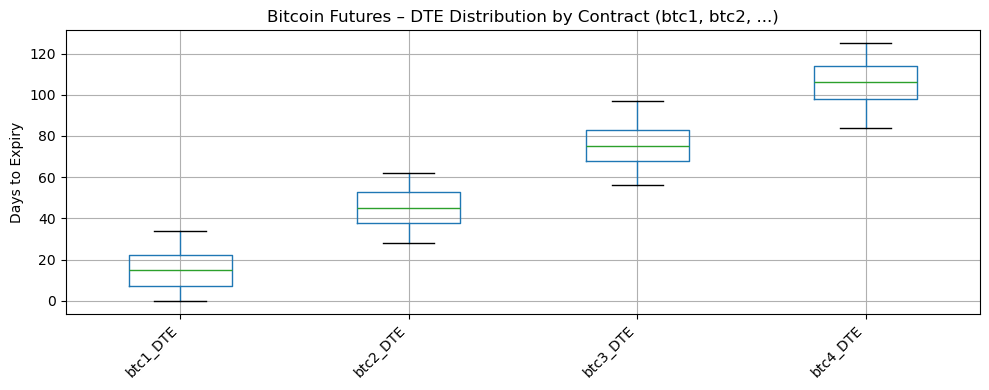

In [5]:


def check_dte_sanity(dte_df: pd.DataFrame, asset: str):
    print(f"\n=== DTE sanity checks for {asset} ===")

    num_negative = (dte_df < 0).sum().sum()
    print(f"Total negative DTE entries: {int(num_negative)}")

    print("\nSummary statistics (days-to-expiry):")
    print(dte_df.describe(percentiles=[0.1, 0.5, 0.9]).T)

    cols = dte_df.columns.tolist()
    violations = 0
    for i in range(len(cols) - 1):
        c1, c2 = cols[i], cols[i + 1]
        bad = (dte_df[c2] < dte_df[c1]).sum()
        violations += bad
        print(f"Pairs {c1} -> {c2}: {int(bad)} non-monotone rows")

    print(f"Total monotonicity violations: {int(violations)}")

    if num_negative > 0 or violations > 0:
        print("\nSample problematic rows:")
        mask = (dte_df < 0).any(axis=1)
        for i in range(len(cols) - 1):
            mask |= (dte_df[cols[i + 1]] < dte_df[cols[i]])
        print(dte_df.loc[mask].head())

check_dte_sanity(gc_dte,  asset="Gold (GC)")
check_dte_sanity(si_dte,  asset="Silver (SI)")
check_dte_sanity(btc_dte, asset="Bitcoin (BTC)")

def plot_dte_boxplots(dte_df: pd.DataFrame, title: str):
    plt.figure()
    dte_df_clean = dte_df.dropna(how="all", axis=1)
    dte_df_clean.boxplot()
    plt.title(title)
    plt.ylabel("Days to Expiry")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

plot_dte_boxplots(gc_dte,  "Gold Futures – DTE Distribution by Contract (GC1, GC2, ...)")
plot_dte_boxplots(si_dte,  "Silver Futures – DTE Distribution by Contract (SI1, SI2, ...)")
plot_dte_boxplots(btc_dte, "Bitcoin Futures – DTE Distribution by Contract (btc1, btc2, ...)")


# Basis calcualtions for median curve annualised for the diagram

In [6]:


def compute_simple_basis(panel: pd.DataFrame, spot_col: str, fut_cols: list[str], suffix: str = "_basis_pct") -> pd.DataFrame:
    """
    Simple % basis (non-annualised): (F/S - 1) * 100
    """
    out = pd.DataFrame(index=panel.index)
    out[spot_col] = panel[spot_col]

    for fc in fut_cols:
        basis_name = f"{fc}{suffix}"
        out[basis_name] = (panel[fc] / panel[spot_col] - 1.0) * 100.0

    return out

gc_basis = compute_simple_basis(
    gc_panel,
    spot_col="XAU",
    fut_cols=[c for c in gc_panel.columns if c != "XAU"],
)

si_basis = compute_simple_basis(
    si_panel,
    spot_col="XAG",
    fut_cols=[c for c in si_panel.columns if c != "XAG"],
)

btc_basis = compute_simple_basis(
    df_btc,
    spot_col="xbt_usd",
    fut_cols=[c for c in df_btc.columns if c != "xbt_usd"],
)

print("GC basis cols:", gc_basis.columns.tolist())
print("SI basis cols:", si_basis.columns.tolist())
print("BTC basis cols:", btc_basis.columns.tolist())

def make_basis_dte_long(basis_df: pd.DataFrame, dte_df: pd.DataFrame, asset_label: str) -> pd.DataFrame:
    """
    Output columns:
      asset, contract, date, DTE, basis_pct
    """
    rows = []
    for basis_col in basis_df.columns:
        if not basis_col.endswith("_basis_pct"):
            continue

        fut = basis_col.replace("_basis_pct", "")
        dte_col = f"{fut}_DTE"
        if dte_col not in dte_df.columns:
            continue

        sub = pd.DataFrame({
            "date": basis_df.index,
            "basis_pct": basis_df[basis_col].values,
            "DTE": dte_df[dte_col].reindex(basis_df.index).values,
        })
        sub["asset"] = asset_label
        sub["contract"] = fut
        sub = sub.dropna(subset=["DTE"])
        sub = sub[sub["DTE"] >= 0]
        rows.append(sub)

    long_df = pd.concat(rows, axis=0, ignore_index=True)
    return long_df

gold_long   = make_basis_dte_long(gc_basis,  gc_dte,  asset_label="Gold")
silver_long = make_basis_dte_long(si_basis,  si_dte,  asset_label="Silver")
btc_long    = make_basis_dte_long(btc_basis, btc_dte, asset_label="Bitcoin")

print(gold_long.head())
print(silver_long.head())
print(btc_long.head())

def median_basis_curve(asset_long_df: pd.DataFrame, asset_name: str, max_dte: int = 310, n_first_contracts: int = 4) -> pd.Series:
    """
    For each integer DTE, take all obs across time and first N futures, compute median basis (%).
    """
    contracts_sorted = sorted(asset_long_df["contract"].unique())
    keep_contracts = contracts_sorted[:n_first_contracts]

    df = asset_long_df[asset_long_df["contract"].isin(keep_contracts)].copy()
    df = df[(df["DTE"] > 0) & (df["DTE"] <= max_dte)]
    df["DTE_int"] = df["DTE"].astype(int)

    median_curve = (
        df.groupby("DTE_int")["basis_pct"]
        .median()
        .sort_index()
        .rename(asset_name)
    )
    return median_curve

btc_median    = median_basis_curve(btc_long,    "BTC")
gold_median   = median_basis_curve(gold_long,   "Gold")
silver_median = median_basis_curve(silver_long, "Silver")

print(btc_median.head())
print(gold_median.head())
print(silver_median.head())

def annualise_basis(basis_df: pd.DataFrame, dte_df: pd.DataFrame, days_in_year: int = 365) -> pd.DataFrame:
    """
    Annualised basis (in % p.a.): basis_pct * (365 / DTE)
    """
    result = pd.DataFrame(index=basis_df.index)

    for col in basis_df.columns:
        if not col.endswith("_basis_pct"):
            continue

        fut = col.replace("_basis_pct", "")
        dte_col = f"{fut}_DTE"
        if dte_col not in dte_df.columns:
            continue

        days = dte_df[dte_col].reindex(basis_df.index).clip(lower=1)
        ann_col = f"{fut}_basis_ann_pct"
        result[ann_col] = basis_df[col] * (days_in_year / days)

    return result

gc_basis_ann  = annualise_basis(gc_basis,  gc_dte)
si_basis_ann  = annualise_basis(si_basis,  si_dte)
btc_basis_ann = annualise_basis(btc_basis, btc_dte)

print("Gold annualised basis columns:", gc_basis_ann.columns.tolist())
print("Silver annualised basis columns:", si_basis_ann.columns.tolist())
print("BTC annualised basis columns:", btc_basis_ann.columns.tolist())

print(gc_basis_ann.head())
print(si_basis_ann.head())
print(btc_basis_ann.head())


GC basis cols: ['XAU', 'GC1_basis_pct', 'GC2_basis_pct', 'GC3_basis_pct', 'GC4_basis_pct', 'GC7_basis_pct']
SI basis cols: ['XAG', 'SI1_basis_pct', 'SI2_basis_pct', 'SI3_basis_pct', 'SI4_basis_pct', 'SI7_basis_pct']
BTC basis cols: ['xbt_usd', 'btc1_basis_pct', 'btc2_basis_pct', 'btc3_basis_pct', 'btc4_basis_pct']
        date  basis_pct   DTE asset contract
0 2018-01-02  -0.110811  55.0  Gold      GC1
1 2018-01-03   0.402830  54.0  Gold      GC1
2 2018-01-04  -0.106575  53.0  Gold      GC1
3 2018-01-05   0.205367  52.0  Gold      GC1
4 2018-01-08   0.000000  49.0  Gold      GC1
        date  basis_pct   DTE   asset contract
0 2018-01-02   0.093077  27.0  Silver      SI1
1 2018-01-03   0.764472  26.0  Silver      SI1
2 2018-01-04   0.235076  25.0  Silver      SI1
3 2018-01-05   0.364646  24.0  Silver      SI1
4 2018-01-08   0.058363  21.0  Silver      SI1
        date  basis_pct   DTE    asset contract
0 2018-01-01        NaN  25.0  Bitcoin     btc1
1 2018-01-02   0.476171  24.0  Bitco

# Mid-curve annualised basis to showcase basis changes over the years

Gold GC2 yearly avg ann. basis (% p.a.):
date
2018    1.43
2019    1.52
2020    1.98
2021    0.28
2022    1.43
2023    3.60
2024    3.57
2025    3.45
Name: GC2_basis_ann_pct, dtype: float64

Silver SI3 yearly avg ann. basis (% p.a.):
date
2018     5.16
2019     5.07
2020     7.42
2021     2.08
2022     4.37
2023    11.41
2024    11.73
2025    11.65
Name: SI3_basis_ann_pct, dtype: float64

=== Gold (GC2): yearly avg ann. basis (% p.a.) ===
date
2018    1.43
2019    1.52
2020    1.98
2021    0.28
2022    1.43
2023    3.60
2024    3.57
2025    3.45
Name: GC2_basis_ann_pct, dtype: float64

Gold (GC2): richest 3-year window ≈ 2023–2025, avg basis ≈ 3.54% p.a.

=== Silver (SI3): yearly avg ann. basis (% p.a.) ===
date
2018     5.16
2019     5.07
2020     7.42
2021     2.08
2022     4.37
2023    11.41
2024    11.73
2025    11.65
Name: SI3_basis_ann_pct, dtype: float64

Silver (SI3): richest 3-year window ≈ 2023–2025, avg basis ≈ 11.60% p.a.


/var/folders/tl/hb3sh0p16wb8f6cdsnkjq_wm0000gn/T/ipykernel_89465/2332194938.py:8: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  gc_yearly = gc_mid.resample("A").mean()
/var/folders/tl/hb3sh0p16wb8f6cdsnkjq_wm0000gn/T/ipykernel_89465/2332194938.py:9: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  si_yearly = si_mid.resample("A").mean()


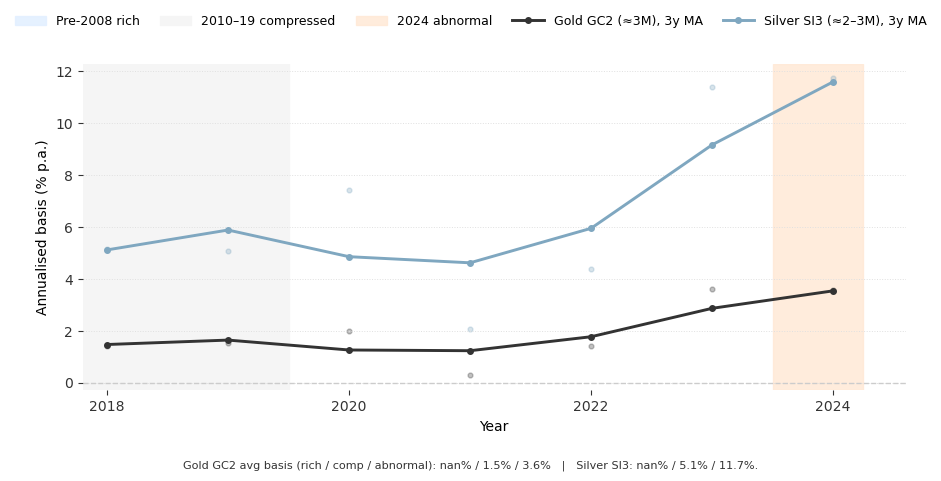

In [7]:


gc_mid = gc_basis_ann.get("GC2_basis_ann_pct", pd.Series(dtype=float)).dropna()
si_mid = si_basis_ann.get("SI3_basis_ann_pct", pd.Series(dtype=float)).dropna()

common_index = gc_mid.index.intersection(si_mid.index)
gc_mid = gc_mid.reindex(common_index)
si_mid = si_mid.reindex(common_index)

gc_yearly = gc_mid.resample("A").mean()
si_yearly = si_mid.resample("A").mean()

gc_yearly.index = gc_yearly.index.year
si_yearly.index = si_yearly.index.year

print("Gold GC2 yearly avg ann. basis (% p.a.):")
print(gc_yearly.round(2))

print("\nSilver SI3 yearly avg ann. basis (% p.a.):")
print(si_yearly.round(2))

def richest_rolling_window_from_yearly(yearly: pd.Series, window_years: int = 3, label: str = "Asset"):
    roll = yearly.rolling(window_years).mean()
    best_end_year = int(roll.idxmax())
    best_start_year = best_end_year - window_years + 1
    print(f"\n=== {label}: yearly avg ann. basis (% p.a.) ===")
    print(yearly.round(2))
    print(f"\n{label}: richest {window_years}-year window ≈ {best_start_year}–{best_end_year}, "
          f"avg basis ≈ {roll.loc[best_end_year]:.2f}% p.a.")
    return (best_start_year, best_end_year)

gc_rich_window = richest_rolling_window_from_yearly(gc_yearly, window_years=3, label="Gold (GC2)")
si_rich_window = richest_rolling_window_from_yearly(si_yearly, window_years=3, label="Silver (SI3)")

DARK_GREY    = "#333333"
SILVER_BLUE  = "#7FA7C0"
LIGHT_GREY   = "#CCCCCC"

ERA_RICH     = "#E3F0FF"
ERA_COMP     = "#F5F5F5"
ERA_ABNORMAL = "#FFE9D6"

def plot_gold_silver_three_regimes_final(
    gc_yearly: pd.Series,
    si_yearly: pd.Series,
    rich_end: int = 2008,
    comp_start: int = 2010,
    comp_end: int = 2019,
    abnormal_start: int = 2024,
    x_end: int = 2024,
):
    gc_smooth = gc_yearly.rolling(3, center=True, min_periods=1).mean()
    si_smooth = si_yearly.rolling(3, center=True, min_periods=1).mean()

    all_years_full = sorted(set(gc_yearly.index) | set(si_yearly.index))
    if not all_years_full:
        raise ValueError("No yearly data available to plot.")
    min_year = min(all_years_full)

    years = [y for y in all_years_full if y <= x_end]
    gc_s = gc_smooth.reindex(years)
    si_s = si_smooth.reindex(years)

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.axvspan(min_year - 0.25, rich_end + 0.5, color=ERA_RICH, alpha=0.9, label="Pre-2008 rich")
    ax.axvspan(comp_start - 0.5, comp_end + 0.5, color=ERA_COMP, alpha=1.0, label="2010–19 compressed")
    ax.axvspan(abnormal_start - 0.5, x_end + 0.25, color=ERA_ABNORMAL, alpha=0.85, label="2024 abnormal")

    ax.plot(years, gc_s.values, color=DARK_GREY, linewidth=2.1, marker="o", markersize=4,
            label="Gold GC2 (≈3M), 3y MA")
    ax.plot(years, si_s.values, color=SILVER_BLUE, linewidth=2.1, marker="o", markersize=4,
            label="Silver SI3 (≈2–3M), 3y MA")

    ax.scatter([y for y in gc_yearly.index if y <= x_end],
               [gc_yearly[y] for y in gc_yearly.index if y <= x_end],
               color=DARK_GREY, s=12, alpha=0.3)
    ax.scatter([y for y in si_yearly.index if y <= x_end],
               [si_yearly[y] for y in si_yearly.index if y <= x_end],
               color=SILVER_BLUE, s=12, alpha=0.3)

    ax.axhline(0, color=LIGHT_GREY, linestyle="--", linewidth=1)

    ax.set_xlabel("Year")
    ax.set_ylabel("Annualised basis (% p.a.)")

    ax.set_xlim(min_year - 0.2, x_end + 0.6)
    ax.set_xticks(range(min_year, x_end + 2, 2))

    ax.yaxis.grid(True, linestyle=":", linewidth=0.7, color="#E0E0E0")
    ax.xaxis.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="both", colors=DARK_GREY)

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.97),
               ncol=len(labels), frameon=False, fontsize=9, columnspacing=1.6, handlelength=2.5)

    plt.tight_layout(rect=[0, 0.08, 1, 0.88])

    def era_mean(series: pd.Series, start: int, end: int | None = None):
        if end is None:
            return series[(series.index >= start) & (series.index <= x_end)].mean()
        return series[(series.index >= start) & (series.index <= end)].mean()

    gc_rich = era_mean(gc_yearly, min_year, rich_end)
    gc_comp = era_mean(gc_yearly, comp_start, comp_end)
    gc_abn  = era_mean(gc_yearly, abnormal_start, x_end)

    si_rich = era_mean(si_yearly, min_year, rich_end)
    si_comp = era_mean(si_yearly, comp_start, comp_end)
    si_abn  = era_mean(si_yearly, abnormal_start, x_end)

    note = (
        f"Gold GC2 avg basis (rich / comp / abnormal): {gc_rich:.1f}% / {gc_comp:.1f}% / {gc_abn:.1f}%   |   "
        f"Silver SI3: {si_rich:.1f}% / {si_comp:.1f}% / {si_abn:.1f}%."
    )
    fig.text(0.5, 0.04, note, ha="center", fontsize=8.1, color=DARK_GREY)

    plt.show()

plot_gold_silver_three_regimes_final(gc_yearly, si_yearly)


## Note: This diagram was to show how asis decay can lead to pnl

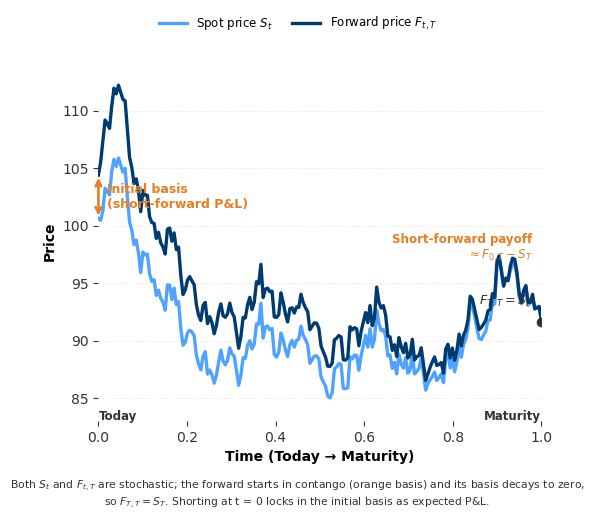

In [8]:
FORWARD_BLUE     = "#003B70"
SPOT_BLUE        = "#4FA3FF"
LIGHT_GREY       = "#DDDDDD"
DARK_GREY        = "#333333"
HIGHLIGHT_ORANGE = "#E67E22"

def plot_forward_spot_stochastic_converging(seed: int = 42):
    np.random.seed(seed)

    n_steps = 200
    t = np.linspace(0, 1, n_steps)

    S0    = 100.0
    mu    = 0.04
    sigma = 0.20
    dt    = 1.0 / 252

    shocks = np.random.normal((mu - 0.5 * sigma**2) * dt,
                              sigma * np.sqrt(dt),
                              size=n_steps)
    log_S = np.log(S0) + np.cumsum(shocks)
    S_t   = np.exp(log_S)

    basis0 = 0.06
    decay_profile = (1 - t) ** 1.2
    base_decay = basis0 * decay_profile

    basis_noise = np.random.normal(0, 0.005, size=n_steps)
    b_t = base_decay + basis_noise
    b_t[-1] = 0.0
    b_t = np.convolve(b_t, np.ones(5) / 5, mode="same")
    b_t[-1] = 0.0

    F_tT = S_t + b_t * S0
    F_tT[-1] = S_t[-1]

    fig, ax = plt.subplots(figsize=(5.4, 5.4))

    ax.plot(t, S_t, color=SPOT_BLUE, linewidth=2.4, label=r"Spot price $S_t$")
    ax.plot(t, F_tT, color=FORWARD_BLUE, linewidth=2.4, label=r"Forward price $F_{t,T}$")

    S0_plot = S_t[0]
    F0_plot = F_tT[0]
    ax.annotate(
        "",
        xy=(0, F0_plot), xytext=(0, S0_plot),
        arrowprops=dict(arrowstyle="<->", color=HIGHLIGHT_ORANGE, linewidth=1.9),
    )
    mid_y0 = 0.5 * (F0_plot + S0_plot)
    ax.text(
        0.02, mid_y0,
        "Initial basis\n(short-forward P&L)",
        ha="left", va="center",
        fontsize=9,
        color=HIGHLIGHT_ORANGE,
        fontweight="bold",
    )

    T = t[-1]
    ST = S_t[-1]
    ax.scatter([T], [ST], color=DARK_GREY, s=35, zorder=4)
    ax.text(
        T - 0.02, ST + 1.0,
        r"$F_{T,T} = S_T$",
        ha="right", va="bottom",
        fontsize=9,
        color=DARK_GREY,
        fontweight="bold",
    )

    ax.text(
        T - 0.02, (F0_plot + ST) / 2,
        r"Short-forward payoff" "\n" r"$\approx F_{0,T} - S_T$",
        ha="right", va="center",
        fontsize=8.5,
        color=HIGHLIGHT_ORANGE,
        fontweight="bold",
    )

    ax.set_xlabel("Time (Today → Maturity)", fontweight="bold")
    ax.set_ylabel("Price", fontweight="bold")

    ymin = min(S_t.min(), F_tT.min())
    ymax = max(S_t.max(), F_tT.max())
    ax.set_xlim(0, 1)
    ax.set_ylim(ymin - 2, ymax + 2)

    ax.text(0, ymin - 1.0, "Today", ha="left", va="top", fontsize=8.5, color=DARK_GREY, fontweight="bold")
    ax.text(T, ymin - 1.0, "Maturity", ha="right", va="top", fontsize=8.5, color=DARK_GREY, fontweight="bold")

    ax.yaxis.grid(True, linestyle=":", linewidth=0.6, color=LIGHT_GREY)
    ax.xaxis.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="both", colors=DARK_GREY)

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.98),
               ncol=len(labels), frameon=False, fontsize=8.5, columnspacing=1.6, handlelength=2.4)

    plt.tight_layout(rect=[0, 0.10, 1, 0.90])

    note = (
        "Both $S_t$ and $F_{t,T}$ are stochastic; the forward starts in contango "
        "(orange basis) and its basis decays to zero,\n"
        "so $F_{T,T} = S_T$. Shorting at t = 0 locks in the initial basis as expected P&L."
    )
    fig.text(0.5, 0.05, note, ha="center", fontsize=7.8, color=DARK_GREY)

    plt.show()

plot_forward_spot_stochastic_converging()


In [9]:
# double checks

def is_last_friday(dt: pd.Timestamp) -> bool:
    return (dt.weekday() == 4) and ((dt + timedelta(days=7)).month != dt.month)

sample = btc_dte[btc_dte["btc1_DTE"] > 0].iloc[::50].copy()

def expiry_from_row(row: pd.Series) -> pd.Timestamp:
    d = row.name
    dte = int(row["btc1_DTE"])
    return d + timedelta(days=dte)

sample["expiry_candidate"] = sample.apply(expiry_from_row, axis=1)
sample["expiry_weekday"]   = sample["expiry_candidate"].dt.weekday
sample["is_last_friday"]   = sample["expiry_candidate"].apply(is_last_friday)

print(sample[["btc1_DTE", "expiry_candidate", "expiry_weekday", "is_last_friday"]].head(15))
print("Weekday value 4 = Friday")
print(sample["is_last_friday"].value_counts())


            btc1_DTE expiry_candidate  expiry_weekday  is_last_friday
date                                                                 
2018-01-01      25.0       2018-01-26               4            True
2018-03-02      28.0       2018-03-30               4            True
2018-05-02      23.0       2018-05-25               4            True
2018-07-02      25.0       2018-07-27               4            True
2018-08-30       1.0       2018-08-31               4            True
2018-10-31      30.0       2018-11-30               4            True
2018-12-31      25.0       2019-01-25               4            True
2019-03-01      28.0       2019-03-29               4            True
2019-05-01      30.0       2019-05-31               4            True
2019-07-01      25.0       2019-07-26               4            True
2019-08-29       1.0       2019-08-30               4            True
2019-10-30      30.0       2019-11-29               4            True
2019-12-30      32.0

# stitching of the panels 

In [10]:


def build_btc_panel(df_btc: pd.DataFrame, btc_dte: pd.DataFrame) -> pd.DataFrame:
    """
    Returns a DataFrame with prices + DTEs aligned.
    """
    price_cols = ["xbt_usd", "btc1", "btc2", "btc3", "btc4"]
    dte_cols   = ["btc1_DTE", "btc2_DTE", "btc3_DTE", "btc4_DTE"]

    panel = (
        df_btc[price_cols]
        .join(btc_dte[dte_cols], how="inner")
        .dropna()
    )
    return panel

def pick_generic_for_expiry(row: pd.Series, current_date: pd.Timestamp, expiry_date: pd.Timestamp) -> str | None:
    """
    Stitching rule:
      remDTE = (T* - t) in days
      choose btc{k} whose DTE is closest to remDTE among k in {1..4}, DTE>0

    NOTE: This *switches the marking series* as DTE rolls down (e.g. btc2 -> btc1),
    but it does NOT model an explicit roll trade/cost at the switch.
    """
    rem_dte = (expiry_date - current_date).days
    if rem_dte <= 0:
        return None

    candidates = []
    for k in range(1, 5):
        dte_col = f"btc{k}_DTE"
        dte_val = row[dte_col]
        if pd.isna(dte_val) or dte_val <= 0:
            continue
        distance = abs(dte_val - rem_dte)
        candidates.append((k, distance))

    if not candidates:
        return None

    best_k = min(candidates, key=lambda x: x[1])[0]
    return f"btc{best_k}"


# BTC backtest running across the for the IS (2018–2022), OOS (2023–2025), and FULL (2018–2025), for stitched futures MTM


In [11]:
IS_START   = pd.Timestamp("2018-01-01")
SPLIT_DATE = pd.Timestamp("2023-01-01")   
OOS_END    = pd.Timestamp("2025-12-31")
IS_END     = SPLIT_DATE - pd.Timedelta(days=1)
ANNUAL_DAYS = 250
def backtest_s1_btc_unit_notional(
    df_btc: pd.DataFrame,
    btc_dte: pd.DataFrame,
    min_dte: int = 60,
    max_dte: int = 120,
    entry_basis_ann_threshold: float = 0.05,   # 5% p.a.
    days_before_expiry_close: int = 5,
    initial_equity: float = 1_000_000.0,
    tc_rate: float = 0.0005,                   # 0.05% per leg
):
    """
    S1 BTC 2–3M basis trade, stitched by DTE.

    Position (per "package"):
      - long  N_btc spot BTC
      - short N_btc BTC notional via futures
      notionals matched 1:1 in BTC terms.

    Sizing (fully funded spot):
      N_btc = equity_prev / S_t

    PnL (while in trade):
      dPnL = N_btc * (dS - dF)

    Mechanics:
      - enter using btc2 or btc3 if DTE in [min_dte, max_dte] and annualised basis exceeds threshold
      - synthetic expiry = entry_date + DTE_start
      - close days_before_expiry_close before expiry
      - futures leg is marked-to-market using DTE-stitch picker (may switch btc2 -> btc1 near end)
      - NO explicit roll trades/costs at stitch switches (only entry/exit TC)
    """
    panel = build_btc_panel(df_btc, btc_dte)
    all_dates = panel.index.sort_values()

    daily_pnl = pd.Series(0.0, index=all_dates, dtype=float)
    daily_ret = pd.Series(0.0, index=all_dates, dtype=float)
    equity    = pd.Series(index=all_dates, dtype=float)

    in_trade = False
    current_trade = None
    trades = []

    prev_S = None
    prev_F = None

    if len(all_dates) == 0:
        stats = {
            "num_trades": 0,
            "total_return": 0.0,
            "cagr": 0.0,
            "ann_vol": 0.0,
            "sharpe": np.nan,
            "max_drawdown": 0.0,
        }
        return {
            "daily_pnl": daily_pnl,
            "daily_ret": daily_ret,
            "equity": equity,
            "trades": pd.DataFrame(),
            "stats": stats,
        }

    eq_prev = float(initial_equity)

    for i, current_date in enumerate(all_dates):
        row = panel.loc[current_date]
        S_t = row["xbt_usd"]
        pnl_t = 0.0

        if prev_S is None:
            prev_S = S_t
            prev_F = None

        # Entries here
        if (not in_trade) and (eq_prev > 0):
            candidates = []
            for k in [2, 3]:
                fut_col = f"btc{k}"
                dte_col = f"{fut_col}_DTE"

                F_k   = row[fut_col]
                dte_k = row[dte_col]

                if pd.isna(dte_k) or dte_k <= 0:
                    continue

                basis_ann = ((F_k - S_t) / S_t) * (365.0 / dte_k)

                if (min_dte <= dte_k <= max_dte) and (basis_ann > entry_basis_ann_threshold):
                    candidates.append({"k": k, "fut_col": fut_col, "basis_ann": basis_ann, "dte": dte_k, "F0": F_k})

            if candidates:
                best = max(candidates, key=lambda x: x["basis_ann"])
                fut_entry_col = best["fut_col"]
                F0 = float(best["F0"])
                DTE_start = int(best["dte"])

                trade_start = current_date
                expiry_date = trade_start + timedelta(days=DTE_start)
                trade_end   = expiry_date - timedelta(days=days_before_expiry_close)
                if trade_end > all_dates[-1]:
                    trade_end = all_dates[-1]

                N_btc = (eq_prev / S_t) if S_t > 0 else 0.0
                if N_btc > 0:
                    spot_notional = N_btc * S_t
                    fut_notional  = N_btc * F0
                    tc_open = tc_rate * (spot_notional + fut_notional)

                    current_trade = {
                        "start": trade_start,
                        "end": trade_end,
                        "tenor_at_entry": fut_entry_col,
                        "S0": float(S_t),
                        "F0": float(F0),
                        "DTE_start": DTE_start,
                        "expiry": expiry_date,
                        "N_btc": float(N_btc),
                    }
                    in_trade = True
                    prev_F = F0
                    pnl_t -= tc_open

        # MTM in the trade
        elif in_trade and current_trade is not None:
            expiry_date = current_trade["expiry"]
            trade_end   = current_trade["end"]
            N_btc       = current_trade["N_btc"]

            if current_date <= trade_end:
                fut_col_today = pick_generic_for_expiry(row, current_date, expiry_date)
                F_t = row[fut_col_today] if fut_col_today is not None else (prev_F if prev_F is not None else 0.0)

                if prev_F is not None:
                    dS = S_t - prev_S
                    dF = F_t - prev_F
                    pnl_t += N_btc * (dS - dF)

                prev_F = F_t

                if current_date == trade_end:
                    spot_notional_close = N_btc * S_t
                    fut_notional_close  = N_btc * F_t
                    tc_close = tc_rate * (spot_notional_close + fut_notional_close)
                    pnl_t -= tc_close

                    trades.append(current_trade)
                    current_trade = None
                    in_trade = False
                    prev_F = None
            else:
                trades.append(current_trade)
                current_trade = None
                in_trade = False
                prev_F = None

        # shows the equity growthj
        daily_pnl.loc[current_date] = pnl_t

        eq_before = eq_prev
        eq_prev   = eq_prev + pnl_t
        equity.loc[current_date] = eq_prev

        daily_ret.loc[current_date] = 0.0 if i == 0 else (pnl_t / eq_before if eq_before != 0 else 0.0)

        prev_S = S_t

    trades_df = pd.DataFrame(trades) if trades else pd.DataFrame(
        columns=["start", "end", "tenor_at_entry", "S0", "F0", "DTE_start", "expiry", "N_btc"]
    )

    equity = equity.dropna()
    total_return = (equity.iloc[-1] / equity.iloc[0] - 1.0) if len(equity) > 1 else 0.0
    n_days = (len(equity) - 1) if len(equity) > 1 else 0
    cagr = ((1.0 + total_return) ** (ANNUAL_DAYS / n_days) - 1.0) if n_days > 0 else 0.0

    ret_series = daily_ret.loc[equity.index].iloc[1:]
    if len(ret_series) > 1:
        mean_daily_ret = ret_series.mean()
        std_daily_ret  = ret_series.std(ddof=1)
        ann_vol        = std_daily_ret * np.sqrt(ANNUAL_DAYS)
        sharpe         = (mean_daily_ret / std_daily_ret * np.sqrt(ANNUAL_DAYS)) if std_daily_ret > 0 else np.nan
    else:
        ann_vol = 0.0
        sharpe  = np.nan

    if len(equity) > 0:
        vals = equity.values
        running_max = np.maximum.accumulate(vals)
        dd = vals / running_max - 1.0
        max_dd = dd.min()
    else:
        max_dd = 0.0

    stats = {
        "num_trades": len(trades_df),
        "total_return": total_return,
        "cagr": cagr,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": max_dd,
    }

    return {
        "daily_pnl": daily_pnl,
        "daily_ret": daily_ret,
        "equity": equity,
        "trades": trades_df,
        "stats": stats,
    }

# actually run all 3 eras

df_btc_era  = df_btc.sort_index().loc[IS_START:OOS_END].copy()
btc_dte_era = btc_dte.sort_index().reindex(df_btc_era.index).loc[IS_START:OOS_END].copy()

results_s1_btc = backtest_s1_btc_unit_notional(
    df_btc_era,
    btc_dte_era,
    min_dte=60,
    max_dte=120,
    entry_basis_ann_threshold=0.05,
    days_before_expiry_close=5,
    initial_equity=1_000_000.0,
    tc_rate=0.0005,
)

print("\n=== S1 BTC FULL (2018–2025) ===")
for k, v in results_s1_btc["stats"].items():
    print(f"{k}: {v}")

# In sample:
df_btc_is  = df_btc_era.loc[IS_START:IS_END]
btc_dte_is = btc_dte_era.loc[IS_START:IS_END]

results_s1_btc_is = backtest_s1_btc_unit_notional(
    df_btc_is,
    btc_dte_is,
    min_dte=60,
    max_dte=120,
    entry_basis_ann_threshold=0.05,
    days_before_expiry_close=5,
    initial_equity=1_000_000.0,
    tc_rate=0.0005,
)

print("\n=== S1 BTC IS (2018–2022) ===")
for k, v in results_s1_btc_is["stats"].items():
    print(f"{k}: {v}")

# Out of sample:
df_btc_oos  = df_btc_era.loc[SPLIT_DATE:OOS_END]
btc_dte_oos = btc_dte_era.loc[SPLIT_DATE:OOS_END]

results_s1_btc_oos = backtest_s1_btc_unit_notional(
    df_btc_oos,
    btc_dte_oos,
    min_dte=60,
    max_dte=120,
    entry_basis_ann_threshold=0.05,
    days_before_expiry_close=5,
    initial_equity=1_000_000.0,
    tc_rate=0.0005,
)

print("\n=== S1 BTC OOS (2023–2025) ===")
for k, v in results_s1_btc_oos["stats"].items():
    print(f"{k}: {v}")




=== S1 BTC FULL (2018–2025) ===
num_trades: 31
total_return: 0.4984452241827326
cagr: 0.06327242193722071
ann_vol: 0.19473759511151448
sharpe: 0.4124348612130007
max_drawdown: -0.17600794981035672

=== S1 BTC IS (2018–2022) ===
num_trades: 18
total_return: 0.2457893342917039
cagr: 0.05953913455663051
ann_vol: 0.21643346873759747
sharpe: 0.3754234853699596
max_drawdown: -0.17600794981035672

=== S1 BTC OOS (2023–2025) ===
num_trades: 13
total_return: 0.2028078768507653
cagr: 0.06847607102119757
ann_vol: 0.1608359731364139
sharpe: 0.492140052398271
max_drawdown: -0.05700774194601721


# Plot BTC equity (rebased) — FULL / IS / OOS

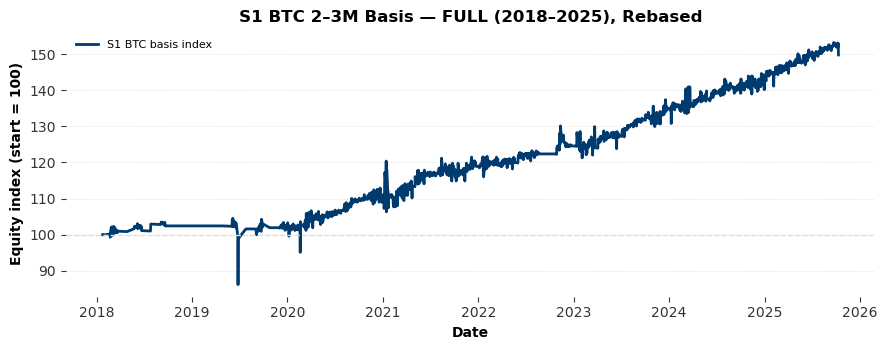

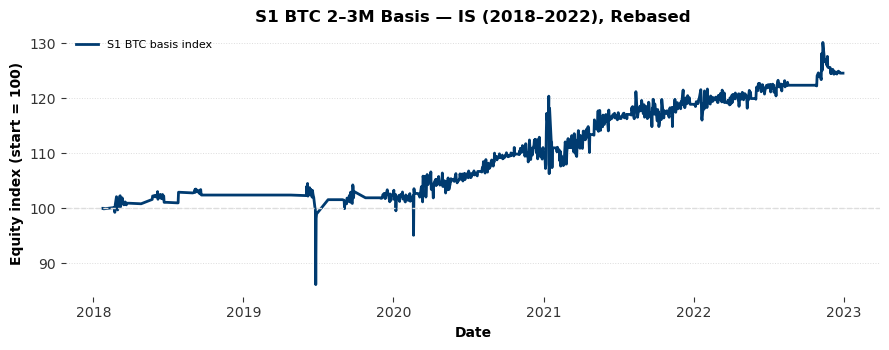

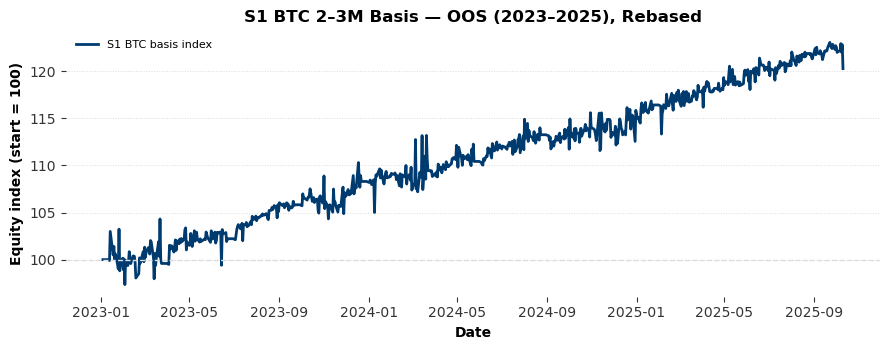

In [12]:
CITI_BLUE  = "#003B70"
LIGHT_GREY = "#DDDDDD"
DARK_GREY  = "#333333"

def plot_equity_rebased(eq: pd.Series, title: str):
    eq = eq.dropna()
    if eq.empty:
        print(f"[plot skipped] empty equity for: {title}")
        return
    eq_rebased = eq / eq.iloc[0] * 100.0

    fig, ax = plt.subplots(figsize=(9, 3.6))
    ax.plot(eq_rebased.index, eq_rebased.values, color=CITI_BLUE, linewidth=2.0, label="S1 BTC basis index")
    ax.axhline(100, color=LIGHT_GREY, linestyle="--", linewidth=1)

    ax.set_ylabel("Equity index (start = 100)", fontweight="bold")
    ax.set_xlabel("Date", fontweight="bold")
    ax.set_title(title, fontweight="bold")

    ax.yaxis.grid(True, linestyle=":", linewidth=0.7, color=LIGHT_GREY)
    ax.xaxis.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="both", colors=DARK_GREY)

    ax.legend(loc="upper left", fontsize=8, frameon=False)
    plt.tight_layout()
    plt.show()

plot_equity_rebased(results_s1_btc["equity"],    "S1 BTC 2–3M Basis — FULL (2018–2025), Rebased")
plot_equity_rebased(results_s1_btc_is["equity"], "S1 BTC 2–3M Basis — IS (2018–2022), Rebased")
plot_equity_rebased(results_s1_btc_oos["equity"],"S1 BTC 2–3M Basis — OOS (2023–2025), Rebased")



In [13]:
from __future__ import annotations

import numpy as np
import pandas as pd
from datetime import timedelta

ANNUAL_DAYS = 252  # keep consistent with your stats helpers


# ------------------------------------------------------
# Robust generic picker (works even if GC5/GC6 missing, GC7 present, etc.)
# ------------------------------------------------------
def pick_generic_for_expiry_from_list(
    row: pd.Series,
    current_date: pd.Timestamp,
    expiry_date: pd.Timestamp,
    fut_cols: list[str],
) -> str | None:
    """
    Choose the futures column whose DTE is closest to remaining days-to-expiry,
    among the futures columns actually present in the row.

    Requires BOTH price col (e.g. "GC7") and DTE col (e.g. "GC7_DTE") to exist.
    """
    rem_dte = (expiry_date - current_date).days
    if rem_dte <= 0:
        return None

    candidates: list[tuple[str, float]] = []
    for fut in fut_cols:
        dte_col = f"{fut}_DTE"
        if (fut not in row.index) or (dte_col not in row.index):
            continue
        dte_val = row[dte_col]
        if pd.isna(dte_val) or float(dte_val) <= 0:
            continue
        dist = abs(float(dte_val) - float(rem_dte))
        candidates.append((fut, dist))

    if not candidates:
        return None

    # closest DTE match
    return min(candidates, key=lambda x: x[1])[0]


# ------------------------------------------------------
# Build spot+futures+DTE panel from your existing wide frames
# ------------------------------------------------------
def build_panel_with_dte(
    price_panel: pd.DataFrame,
    dte_panel: pd.DataFrame,
    spot_col: str,
    fut_cols: list[str],
) -> pd.DataFrame:
    fut_cols = [c for c in fut_cols if c in price_panel.columns]
    dte_cols = [f"{c}_DTE" for c in fut_cols if f"{c}_DTE" in dte_panel.columns]

    panel = (
        price_panel[[spot_col] + fut_cols]
        .join(dte_panel[dte_cols], how="inner")
        .dropna()
        .sort_index()
    )
    return panel


# ------------------------------------------------------
# S1 backtest (GC/SI) — matches your old logic, but robust
# ------------------------------------------------------
def backtest_s1_metal_unit_notional(
    panel_full: pd.DataFrame,
    asset_label: str,
    spot_col: str,
    fut_cols: list[str],                 # all available futures for stitching
    entry_cols: list[str],               # typically ["GC2","GC3"] or ["SI2","SI3"]
    min_dte: int = 60,
    max_dte: int = 120,
    entry_basis_ann_threshold: float = 0.02,
    days_before_expiry_close: int = 5,
    initial_equity: float = 1_000_000.0,
    tc_rate: float = 0.0005,
    capital_fraction: float = 1.0,
):
    """
    Long spot / short futures, USD notionals matched via N_units = capital_fraction * equity / spot.
    Enter using the richer of entry_cols (basis_ann), provided DTE in [min_dte, max_dte] and basis_ann > threshold.
    Hold until (synthetic expiry - days_before_expiry_close). During hold, stitch by closest remaining DTE.
    """
    panel = panel_full.copy()
    all_dates = panel.index.sort_values()

    daily_pnl = pd.Series(0.0, index=all_dates, dtype=float)
    daily_ret = pd.Series(0.0, index=all_dates, dtype=float)
    equity    = pd.Series(index=all_dates, dtype=float)

    in_trade = False
    current_trade = None
    trades = []

    prev_S = None
    prev_F = None

    if len(all_dates) == 0:
        return {
            "daily_pnl": daily_pnl,
            "daily_ret": daily_ret,
            "equity": equity,
            "trades": pd.DataFrame(),
            "stats": {
                "num_trades": 0,
                "total_return": 0.0,
                "cagr": 0.0,
                "ann_vol": 0.0,
                "sharpe": np.nan,
                "max_drawdown": 0.0,
            },
        }

    eq_prev = float(initial_equity)

    for i, current_date in enumerate(all_dates):
        row = panel.loc[current_date]
        S_t = float(row[spot_col])
        pnl_t = 0.0

        if prev_S is None:
            prev_S = S_t
            prev_F = None

        # ---------------- ENTRY ----------------
        if (not in_trade) and (eq_prev > 0.0):
            candidates = []
            for fut in entry_cols:
                dte_col = f"{fut}_DTE"
                if (fut not in row.index) or (dte_col not in row.index):
                    continue

                F_k = float(row[fut])
                dte_k = float(row[dte_col])
                if (not np.isfinite(dte_k)) or dte_k <= 0:
                    continue

                basis_ann = ((F_k - S_t) / S_t) * (365.0 / dte_k)

                if (min_dte <= dte_k <= max_dte) and (basis_ann > entry_basis_ann_threshold):
                    candidates.append((fut, basis_ann, dte_k, F_k))

            if candidates:
                # pick the highest annualised basis
                fut_entry, basis_ann_entry, dte_start, F0 = max(candidates, key=lambda x: x[1])

                trade_start = current_date
                expiry_date = trade_start + timedelta(days=int(round(dte_start)))
                trade_end   = expiry_date - timedelta(days=days_before_expiry_close)

                # clamp to available history
                last_date = all_dates[-1]
                if trade_end > last_date:
                    trade_end = last_date

                # sizing: spot leg consumes capital_fraction * equity
                N_units = (capital_fraction * eq_prev / S_t) if S_t > 0 else 0.0

                if N_units > 0:
                    # costs on both legs (open)
                    tc_open = tc_rate * ((N_units * S_t) + (N_units * F0))
                    pnl_t -= tc_open

                    current_trade = {
                        "asset": asset_label,
                        "start": trade_start,
                        "end": trade_end,
                        "expiry": expiry_date,
                        "tenor_at_entry": fut_entry,
                        "S0": S_t,
                        "F0": F0,
                        "DTE_start": float(dte_start),
                        "basis_ann_at_entry": float(basis_ann_entry),
                        "N_units": float(N_units),
                        "capital_fraction": float(capital_fraction),
                    }
                    in_trade = True
                    prev_F = F0

        # ---------------- MTM WHILE IN TRADE ----------------
        elif in_trade and (current_trade is not None):
            expiry_date = current_trade["expiry"]
            trade_end   = current_trade["end"]
            N_units     = float(current_trade["N_units"])

            if current_date <= trade_end:
                fut_today = pick_generic_for_expiry_from_list(
                    row=row,
                    current_date=current_date,
                    expiry_date=expiry_date,
                    fut_cols=fut_cols,
                )
                if fut_today is not None:
                    F_t = float(row[fut_today])
                else:
                    F_t = float(prev_F) if prev_F is not None else 0.0

                if prev_F is not None:
                    dS = S_t - float(prev_S)
                    dF = F_t - float(prev_F)
                    pnl_t += N_units * (dS - dF)

                prev_F = F_t

                # exit
                if current_date == trade_end:
                    tc_close = tc_rate * ((N_units * S_t) + (N_units * F_t))
                    pnl_t -= tc_close

                    trades.append(current_trade)
                    current_trade = None
                    in_trade = False
                    prev_F = None

            else:
                # safety close
                trades.append(current_trade)
                current_trade = None
                in_trade = False
                prev_F = None

        # ---------------- EQUITY UPDATE ----------------
        daily_pnl.loc[current_date] = pnl_t
        eq_before = eq_prev
        eq_prev = eq_prev + pnl_t
        equity.loc[current_date] = eq_prev

        daily_ret.loc[current_date] = 0.0 if i == 0 else (pnl_t / eq_before if eq_before != 0 else 0.0)

        prev_S = S_t

    # trades frame
    trades_df = pd.DataFrame(trades) if trades else pd.DataFrame(columns=[
        "asset","start","end","expiry","tenor_at_entry","S0","F0","DTE_start",
        "basis_ann_at_entry","N_units","capital_fraction",
    ])

    # stats (same style as your older backtests)
    eq_clean = equity.dropna().astype(float)
    if len(eq_clean) > 1:
        total_return = float(eq_clean.iloc[-1] / eq_clean.iloc[0] - 1.0)
        n_days = int(len(eq_clean) - 1)
        cagr = (1.0 + total_return) ** (ANNUAL_DAYS / n_days) - 1.0 if n_days > 0 else 0.0

        rets = eq_clean.pct_change().dropna()
        if len(rets) > 1:
            mu = float(rets.mean())
            sd = float(rets.std(ddof=1))
            ann_vol = sd * np.sqrt(ANNUAL_DAYS) if sd > 0 else 0.0
            sharpe  = (mu / sd) * np.sqrt(ANNUAL_DAYS) if sd > 0 else np.nan
        else:
            ann_vol, sharpe = 0.0, np.nan

        vals = eq_clean.values
        running_max = np.maximum.accumulate(vals)
        dd = vals / running_max - 1.0
        max_dd = float(dd.min())
    else:
        total_return, cagr, ann_vol, sharpe, max_dd = 0.0, 0.0, 0.0, np.nan, 0.0

    return {
        "daily_pnl": daily_pnl,
        "daily_ret": daily_ret,
        "equity": eq_clean,
        "trades": trades_df,
        "stats": {
            "num_trades": int(len(trades_df)),
            "total_return": total_return,
            "cagr": cagr,
            "ann_vol": ann_vol,
            "sharpe": sharpe,
            "max_drawdown": max_dd,
        },
    }


# ------------------------------------------------------
# Wire it exactly like your notebook expects:
# results_s1_gc / results_s1_si exist, plus IS/OOS variants
# ------------------------------------------------------

# 1) Determine BTC-era start (same as your old logic)
btc_first_start = results_s1_btc["trades"]["start"].min()
print("BTC-era start (first BTC trade):", btc_first_start)

IS_END_FOR_TABLE = pd.Timestamp("2022-12-31")  # keep identical to your plotting block

# 2) Build GC/SI panels (use what you actually have: GC1-4,GC7 and SI1-4,SI7)
gc_futs_all = [c for c in ["GC1","GC2","GC3","GC4","GC7"] if c in gc_panel.columns]
si_futs_all = [c for c in ["SI1","SI2","SI3","SI4","SI7"] if c in si_panel.columns]

gc_panel_full = build_panel_with_dte(gc_panel, gc_dte, spot_col="XAU", fut_cols=gc_futs_all)
si_panel_full = build_panel_with_dte(si_panel, si_dte, spot_col="XAG", fut_cols=si_futs_all)

# 3) Restrict to BTC-era (important for apples-to-apples)
gc_panel_gc_era = gc_panel_full.loc[gc_panel_full.index >= btc_first_start].copy()
si_panel_si_era = si_panel_full.loc[si_panel_full.index >= btc_first_start].copy()

# 4) FULL results (these are the variables your plotting/stats cell needs)
results_s1_gc = backtest_s1_metal_unit_notional(
    panel_full=gc_panel_gc_era,
    asset_label="GC",
    spot_col="XAU",
    fut_cols=gc_futs_all,
    entry_cols=[c for c in ["GC2","GC3"] if c in gc_futs_all],
    min_dte=60,
    max_dte=120,
    entry_basis_ann_threshold=0.02,
    days_before_expiry_close=5,
    initial_equity=1_000_000.0,
    tc_rate=0.0005,
    capital_fraction=1.0,
)

results_s1_si = backtest_s1_metal_unit_notional(
    panel_full=si_panel_si_era,
    asset_label="SI",
    spot_col="XAG",
    fut_cols=si_futs_all,
    entry_cols=[c for c in ["SI2","SI3"] if c in si_futs_all],
    min_dte=60,
    max_dte=120,
    entry_basis_ann_threshold=0.02,
    days_before_expiry_close=5,
    initial_equity=1_000_000.0,
    tc_rate=0.0005,
    capital_fraction=0.5,   # preserve your old SI sizing
)

print("\n=== S1 GC stats (FULL, BTC-era) ===")
for k, v in results_s1_gc["stats"].items():
    print(f"{k}: {v}")

print("\n=== S1 SI stats (FULL, BTC-era) ===")
for k, v in results_s1_si["stats"].items():
    print(f"{k}: {v}")

# 5) Optional: IS/OOS variants (nice to have; doesn't break anything)
def _slice_panel_is_oos(panel: pd.DataFrame, is_end: pd.Timestamp):
    p_is  = panel.loc[panel.index <= is_end].copy()
    p_oos = panel.loc[panel.index >  is_end].copy()
    return p_is, p_oos

gc_is_panel, gc_oos_panel = _slice_panel_is_oos(gc_panel_gc_era, IS_END_FOR_TABLE)
si_is_panel, si_oos_panel = _slice_panel_is_oos(si_panel_si_era, IS_END_FOR_TABLE)

results_s1_gc_is = backtest_s1_metal_unit_notional(
    panel_full=gc_is_panel,
    asset_label="GC",
    spot_col="XAU",
    fut_cols=gc_futs_all,
    entry_cols=[c for c in ["GC2","GC3"] if c in gc_futs_all],
    min_dte=60,
    max_dte=120,
    entry_basis_ann_threshold=0.02,
    days_before_expiry_close=5,
    initial_equity=1_000_000.0,
    tc_rate=0.0005,
    capital_fraction=1.0,
)

results_s1_gc_oos = backtest_s1_metal_unit_notional(
    panel_full=gc_oos_panel,
    asset_label="GC",
    spot_col="XAU",
    fut_cols=gc_futs_all,
    entry_cols=[c for c in ["GC2","GC3"] if c in gc_futs_all],
    min_dte=60,
    max_dte=120,
    entry_basis_ann_threshold=0.02,
    days_before_expiry_close=5,
    initial_equity=float(results_s1_gc_is["equity"].iloc[-1]) if len(results_s1_gc_is["equity"]) else 1_000_000.0,
    tc_rate=0.0005,
    capital_fraction=1.0,
)

results_s1_si_is = backtest_s1_metal_unit_notional(
    panel_full=si_is_panel,
    asset_label="SI",
    spot_col="XAG",
    fut_cols=si_futs_all,
    entry_cols=[c for c in ["SI2","SI3"] if c in si_futs_all],
    min_dte=60,
    max_dte=120,
    entry_basis_ann_threshold=0.02,
    days_before_expiry_close=5,
    initial_equity=1_000_000.0,
    tc_rate=0.0005,
    capital_fraction=0.5,
)

results_s1_si_oos = backtest_s1_metal_unit_notional(
    panel_full=si_oos_panel,
    asset_label="SI",
    spot_col="XAG",
    fut_cols=si_futs_all,
    entry_cols=[c for c in ["SI2","SI3"] if c in si_futs_all],
    min_dte=60,
    max_dte=120,
    entry_basis_ann_threshold=0.02,
    days_before_expiry_close=5,
    initial_equity=float(results_s1_si_is["equity"].iloc[-1]) if len(results_s1_si_is["equity"]) else 1_000_000.0,
    tc_rate=0.0005,
    capital_fraction=0.5,
)


BTC-era start (first BTC trade): 2018-01-26 00:00:00

=== S1 GC stats (FULL, BTC-era) ===
num_trades: 33
total_return: 0.22232403777959697
cagr: 0.02642031145039425
ann_vol: 0.06357143119668858
sharpe: 0.4419830994947746
max_drawdown: -0.04702995275842148

=== S1 SI stats (FULL, BTC-era) ===
num_trades: 45
total_return: 0.3286899592524186
cagr: 0.037585970692953996
ann_vol: 0.06173147506725443
sharpe: 0.628571060448477
max_drawdown: -0.03936208655867379


# Summary stats + IS/OOS compact chart with the ann return (CAGR), ann vol, Sharpe, max DD, Calmar, VaR95 (daily), CVaR95 (daily); Diagram rebased to 100


=== Summary stats (FULL / IS / OOS) ===
            ann_return_%  ann_vol_%  Sharpe  max_drawdown_%  Calmar  \
strategy                                                              
BTC (FULL)         6.404     19.563   0.415         -17.601   0.364   
BTC (IS)           6.044     21.753   0.379         -17.601   0.343   
BTC (OOS)          6.904     16.148   0.494          -5.701   1.211   
GC (FULL)          2.642      6.357   0.442          -4.703   0.562   
GC (IS)            2.245      6.363   0.381          -4.703   0.477   
GC (OOS)           3.450      6.353   0.566          -2.743   1.258   
SI (FULL)          3.759      6.173   0.629          -3.936   0.955   
SI (IS)            2.461      6.255   0.420          -3.936   0.625   
SI (OOS)           6.248      6.027   1.036          -2.712   2.304   

            VaR_95%_daily_%  CVaR_95%_daily_%  
strategy                                       
BTC (FULL)           -1.588            -2.696  
BTC (IS)             -1.663      

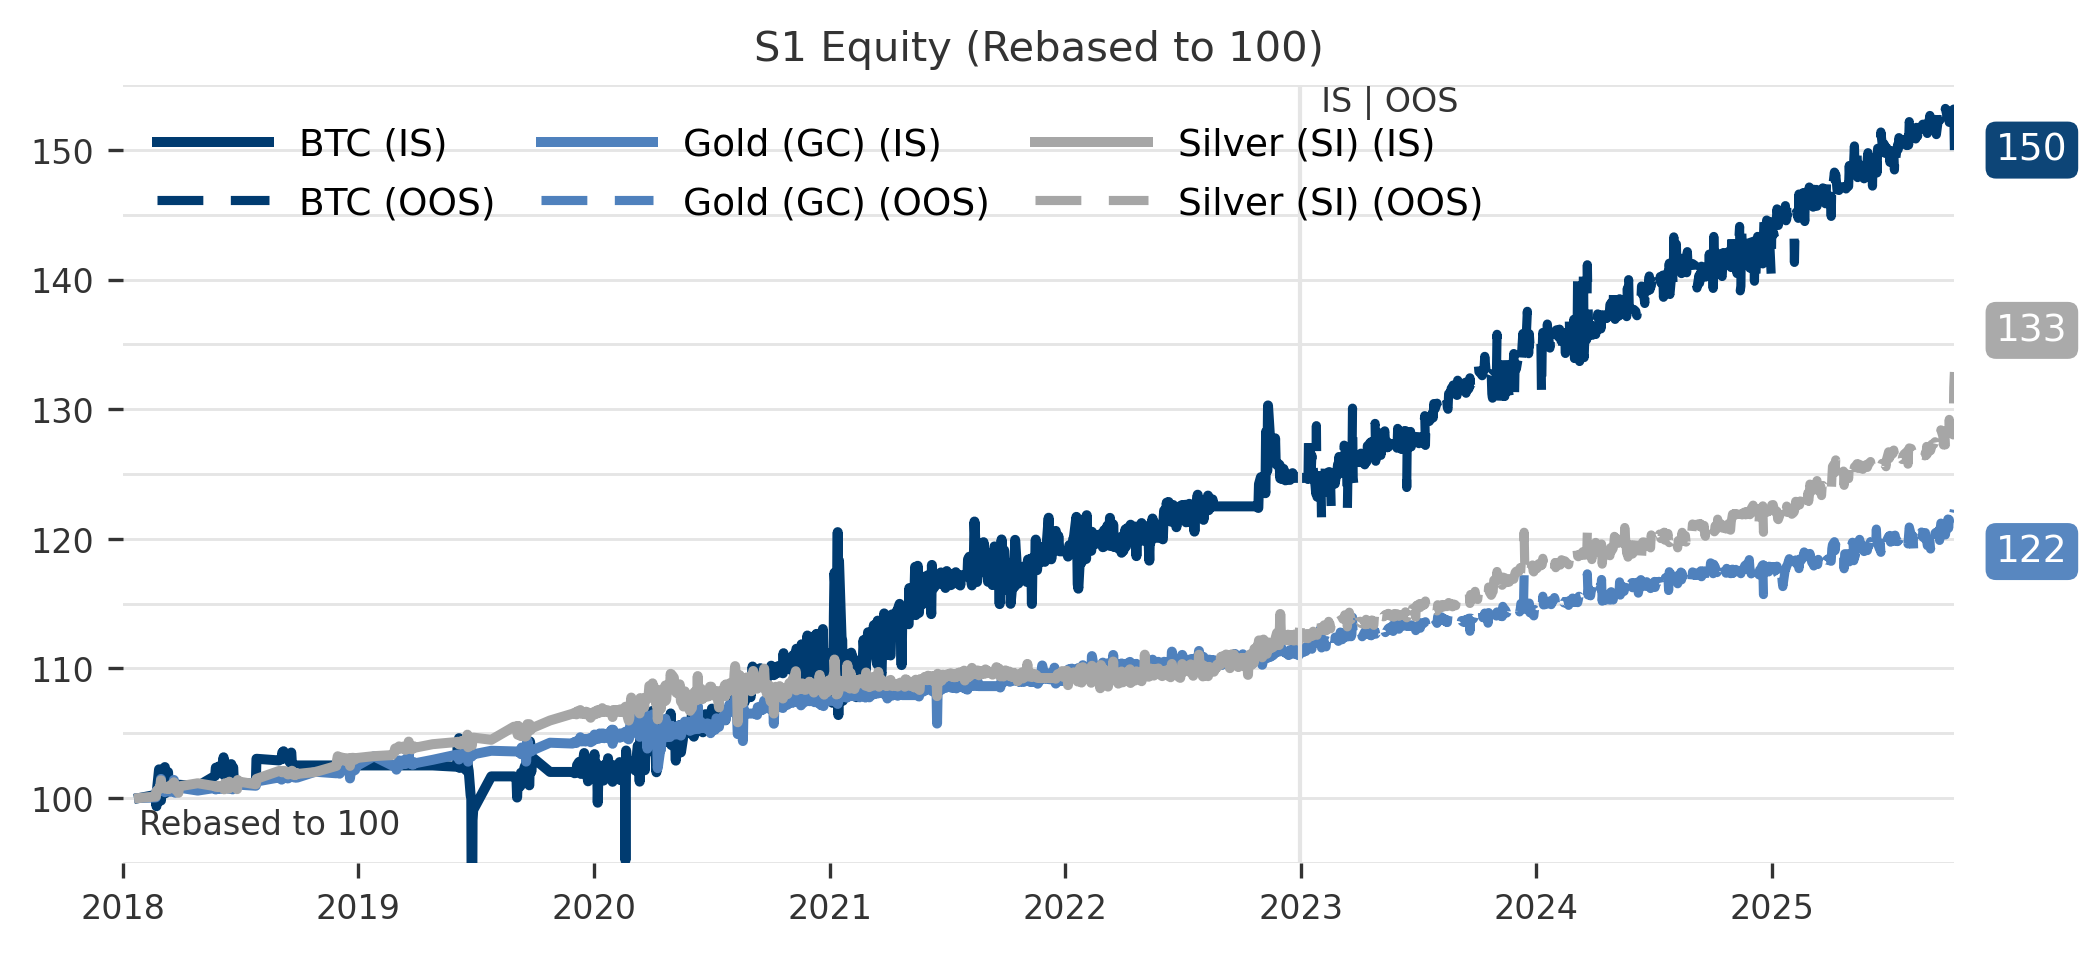

In [14]:


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ANNUAL_DAYS = 252

def _max_drawdown(eq: pd.Series) -> float:
    eq = eq.dropna().astype(float)
    if len(eq) < 2:
        return 0.0
    vals = eq.values
    running_max = np.maximum.accumulate(vals)
    dd = vals / running_max - 1.0
    return float(dd.min())

def _var_cvar_daily(rets: pd.Series, alpha: float = 0.05) -> tuple[float, float]:
    r = rets.dropna().astype(float)
    if r.empty:
        return (np.nan, np.nan)
    var = float(np.quantile(r, alpha))
    tail = r[r <= var]
    cvar = float(tail.mean()) if len(tail) > 0 else var
    return (var, cvar)

def summary_stats_from_equity(eq: pd.Series, name: str) -> pd.Series:
    """
    Summary stats from an equity curve.
    VaR/CVaR: daily return distribution, 95% (alpha=0.05).
    """
    eq = eq.dropna().astype(float)
    if len(eq) < 2:
        return pd.Series(
            {
                "strategy": name,
                "ann_return_%": np.nan,
                "ann_vol_%": np.nan,
                "Sharpe": np.nan,
                "max_drawdown_%": np.nan,
                "Calmar": np.nan,
                "VaR_95%_daily_%": np.nan,
                "CVaR_95%_daily_%": np.nan,
            }
        )

    rets = eq.pct_change().dropna()
    if rets.empty:
        return pd.Series(
            {
                "strategy": name,
                "ann_return_%": np.nan,
                "ann_vol_%": np.nan,
                "Sharpe": np.nan,
                "max_drawdown_%": np.nan,
                "Calmar": np.nan,
                "VaR_95%_daily_%": np.nan,
                "CVaR_95%_daily_%": np.nan,
            }
        )

    total_return = float(eq.iloc[-1] / eq.iloc[0] - 1.0)
    n_days = int(len(eq) - 1)
    cagr = (1.0 + total_return) ** (ANNUAL_DAYS / n_days) - 1.0 if n_days > 0 else np.nan

    mean_d = float(rets.mean())
    std_d  = float(rets.std(ddof=1))
    ann_vol = std_d * np.sqrt(ANNUAL_DAYS) if std_d > 0 else np.nan
    sharpe  = (mean_d / std_d) * np.sqrt(ANNUAL_DAYS) if std_d > 0 else np.nan

    max_dd = _max_drawdown(eq)  # negative
    calmar = (cagr / abs(max_dd)) if (max_dd < 0 and np.isfinite(cagr)) else np.nan

    var95, cvar95 = _var_cvar_daily(rets, alpha=0.05)

    return pd.Series(
        {
            "strategy": name,
            "ann_return_%": 100.0 * cagr,
            "ann_vol_%": 100.0 * ann_vol,
            "Sharpe": sharpe,
            "max_drawdown_%": 100.0 * max_dd,
            "Calmar": calmar,
            "VaR_95%_daily_%": 100.0 * var95,
            "CVaR_95%_daily_%": 100.0 * cvar95,
        }
    )

def _split_is_oos(eq: pd.Series, is_end: pd.Timestamp) -> tuple[pd.Series, pd.Series]:
    eq = eq.dropna().astype(float)
    return eq.loc[eq.index <= is_end].copy(), eq.loc[eq.index > is_end].copy()

# Sumamry tables
def stats_full_is_oos(eq: pd.Series, base_name: str, is_end: pd.Timestamp) -> pd.DataFrame:
    eq = eq.dropna().astype(float)
    eq_is, eq_oos = _split_is_oos(eq, is_end)

    s_full = summary_stats_from_equity(eq,     f"{base_name} (FULL)")
    s_is   = summary_stats_from_equity(eq_is,  f"{base_name} (IS)")
    s_oos  = summary_stats_from_equity(eq_oos, f"{base_name} (OOS)")

    return pd.DataFrame([s_full, s_is, s_oos]).set_index("strategy")

# The plot:
def plot_s1_equity_curves_is_oos_compact(
    btc_eq: pd.Series, gc_eq: pd.Series, si_eq: pd.Series,
    is_end="2022-12-31",
    title="S1 Equity (Rebased to 100)",
    out_pdf="s1_equity_rebased_100_is_oos_compact.pdf",
    out_png="s1_equity_rebased_100_is_oos_compact.png",
    figsize=(6.6, 3.6),
    y_min_fixed=95.0,
    y_grid_step=5.0,
    add_end_bubbles=True,
):
    is_end = pd.Timestamp(is_end)

    eq_btc_raw = btc_eq.dropna().astype(float)
    eq_gc_raw  = gc_eq.dropna().astype(float)
    eq_si_raw  = si_eq.dropna().astype(float)

    common_index = (
        eq_btc_raw.index
        .intersection(eq_gc_raw.index)
        .intersection(eq_si_raw.index)
    ).sort_values()

    eq_btc = eq_btc_raw.reindex(common_index)
    eq_gc  = eq_gc_raw.reindex(common_index)
    eq_si  = eq_si_raw.reindex(common_index)

    if common_index.empty:
        raise ValueError("No common index across BTC/GC/SI equity curves.")

    base_date = common_index[0]
    btc_idx = eq_btc / float(eq_btc.loc[base_date]) * 100.0
    gc_idx  = eq_gc  / float(eq_gc.loc[base_date])  * 100.0
    si_idx  = eq_si  / float(eq_si.loc[base_date])  * 100.0

    # Theme colours, with different for OOS to IS
    DARK  = "#333333"
    LIGHT = "#E5E5E5"

    C_BTC = "#003B70"
    C_GC  = "#4F81BD"
    C_SI  = "#A6A6A6"

    LW_IS, LW_OOS = 2.4, 2.2
    LS_IS, LS_OOS = "-", (0, (5, 3))

    fig, ax = plt.subplots(figsize=figsize, dpi=300)

    def _plot_split(series: pd.Series, color: str):
        s_is  = series.loc[series.index <= is_end]
        s_oos = series.loc[series.index >  is_end]

        h_is = h_oos = None

        if not s_is.empty:
            (h_is,) = ax.plot(s_is.index, s_is.values, color=color, linewidth=LW_IS, linestyle=LS_IS)

        if not s_oos.empty:
            # connect last IS point to first OOS point - this to shoqw difference
            if (not s_is.empty) and (s_is.index[-1] < s_oos.index[0]):
                s_oos = pd.concat([s_is.iloc[[-1]], s_oos])
            (h_oos,) = ax.plot(s_oos.index, s_oos.values, color=color, linewidth=LW_OOS, linestyle=LS_OOS)

        return h_is, h_oos

    h_btc_is, h_btc_oos = _plot_split(btc_idx, C_BTC)
    h_gc_is,  h_gc_oos  = _plot_split(gc_idx,  C_GC)
    h_si_is,  h_si_oos  = _plot_split(si_idx,  C_SI)

    y_max = float(max(btc_idx.max(), gc_idx.max(), si_idx.max()))
    y_floor = float(y_min_fixed)
    y_ceil = float(y_grid_step * np.ceil(y_max / y_grid_step))

    for y in np.arange(y_floor, y_ceil + 1e-9, y_grid_step):
        ax.axhline(y, color=LIGHT, linewidth=0.7, zorder=0)

    ax.set_ylim(y_floor, y_ceil)
    ax.set_xlim(btc_idx.index[0], btc_idx.index[-1])

    # dividing both sampoles 
    if btc_idx.index.min() <= is_end <= btc_idx.index.max():
        ax.axvline(is_end, color=LIGHT, linewidth=1.0)
        ax.text(is_end, y_ceil, "  IS | OOS", fontsize=8, color=DARK, ha="left", va="top")

    ax.set_title(title, fontsize=10, color=DARK, pad=6)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="both", colors=DARK, labelsize=8)
    for spine in ax.spines.values():
        spine.set_visible(False)

    years = sorted({d.year for d in btc_idx.index})
    year_ticks = [pd.Timestamp(year=y, month=1, day=1) for y in years]
    ax.set_xticks(year_ticks)
    ax.set_xticklabels([str(y.year) for y in year_ticks])

    ax.text(btc_idx.index[0], 100.0 - 0.8, "Rebased to 100", fontsize=8, color=DARK, ha="left", va="top")

    handles = [h_btc_is, h_btc_oos, h_gc_is, h_gc_oos, h_si_is, h_si_oos]
    labels  = ["BTC (IS)", "BTC (OOS)", "Gold (GC) (IS)", "Gold (GC) (OOS)", "Silver (SI) (IS)", "Silver (SI) (OOS)"]
    handles_labels = [(h, l) for h, l in zip(handles, labels) if h is not None]
    handles, labels = zip(*handles_labels)

    ax.legend(
        handles, labels,
        ncol=3,
        loc="upper left",
        bbox_to_anchor=(0.00, 0.99),
        frameon=False,
        fontsize=9,
        handlelength=3.0,
        handletextpad=0.8,
        columnspacing=1.2,
        labelspacing=0.6,
    )

    # End bubbles for each asset (to show how much cumulative)
    if add_end_bubbles:
        def _bubble(series: pd.Series, color: str, dy_pts: int):
            last_date = series.index[-1]
            last_val  = float(series.iloc[-1])
            ax.annotate(
                f"{int(round(last_val))}",
                xy=(last_date, last_val),
                xytext=(10, dy_pts),
                textcoords="offset points",
                ha="left", va="center",
                fontsize=9,
                color="white",
                bbox=dict(boxstyle="round,pad=0.28", facecolor=color, edgecolor="none", alpha=0.95),
                zorder=5,
                clip_on=False
            )

        _bubble(btc_idx, C_BTC,  0)
        _bubble(si_idx,  C_SI, +10)
        _bubble(gc_idx,  C_GC, -10)

    fig.subplots_adjust(left=0.06, right=0.985, top=0.88, bottom=0.16)

    fig.savefig(out_pdf, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.show()

    return btc_idx, gc_idx, si_idx



btc_first_start = results_s1_btc["trades"]["start"].min()

eq_btc_full = results_s1_btc["equity"].dropna().astype(float)
eq_gc_full  = results_s1_gc["equity"].dropna().astype(float)
eq_si_full  = results_s1_si["equity"].dropna().astype(float)

eq_btc_full = eq_btc_full.loc[eq_btc_full.index >= btc_first_start]
eq_gc_full  = eq_gc_full.loc[eq_gc_full.index  >= btc_first_start]
eq_si_full  = eq_si_full.loc[eq_si_full.index  >= btc_first_start]

IS_END_FOR_TABLE = pd.Timestamp("2022-12-31")

btc_stats = stats_full_is_oos(eq_btc_full, "BTC", IS_END_FOR_TABLE)
gc_stats  = stats_full_is_oos(eq_gc_full,  "GC",  IS_END_FOR_TABLE)
si_stats  = stats_full_is_oos(eq_si_full,  "SI",  IS_END_FOR_TABLE)

summary_table = pd.concat([btc_stats, gc_stats, si_stats], axis=0)
print("\n=== Summary stats (FULL / IS / OOS) ===")
print(summary_table.round(3))

btc_idx, gc_idx, si_idx = plot_s1_equity_curves_is_oos_compact(
    eq_btc_full, eq_gc_full, eq_si_full,
    is_end="2022-12-31",
    title="S1 Equity (Rebased to 100)",
    out_pdf="s1_equity_rebased_100_is_oos_compact.pdf",
    out_png="s1_equity_rebased_100_is_oos_compact.png",
    figsize=(6.6, 3.6),
    y_min_fixed=95.0,
    y_grid_step=5.0,
    add_end_bubbles=True,
)


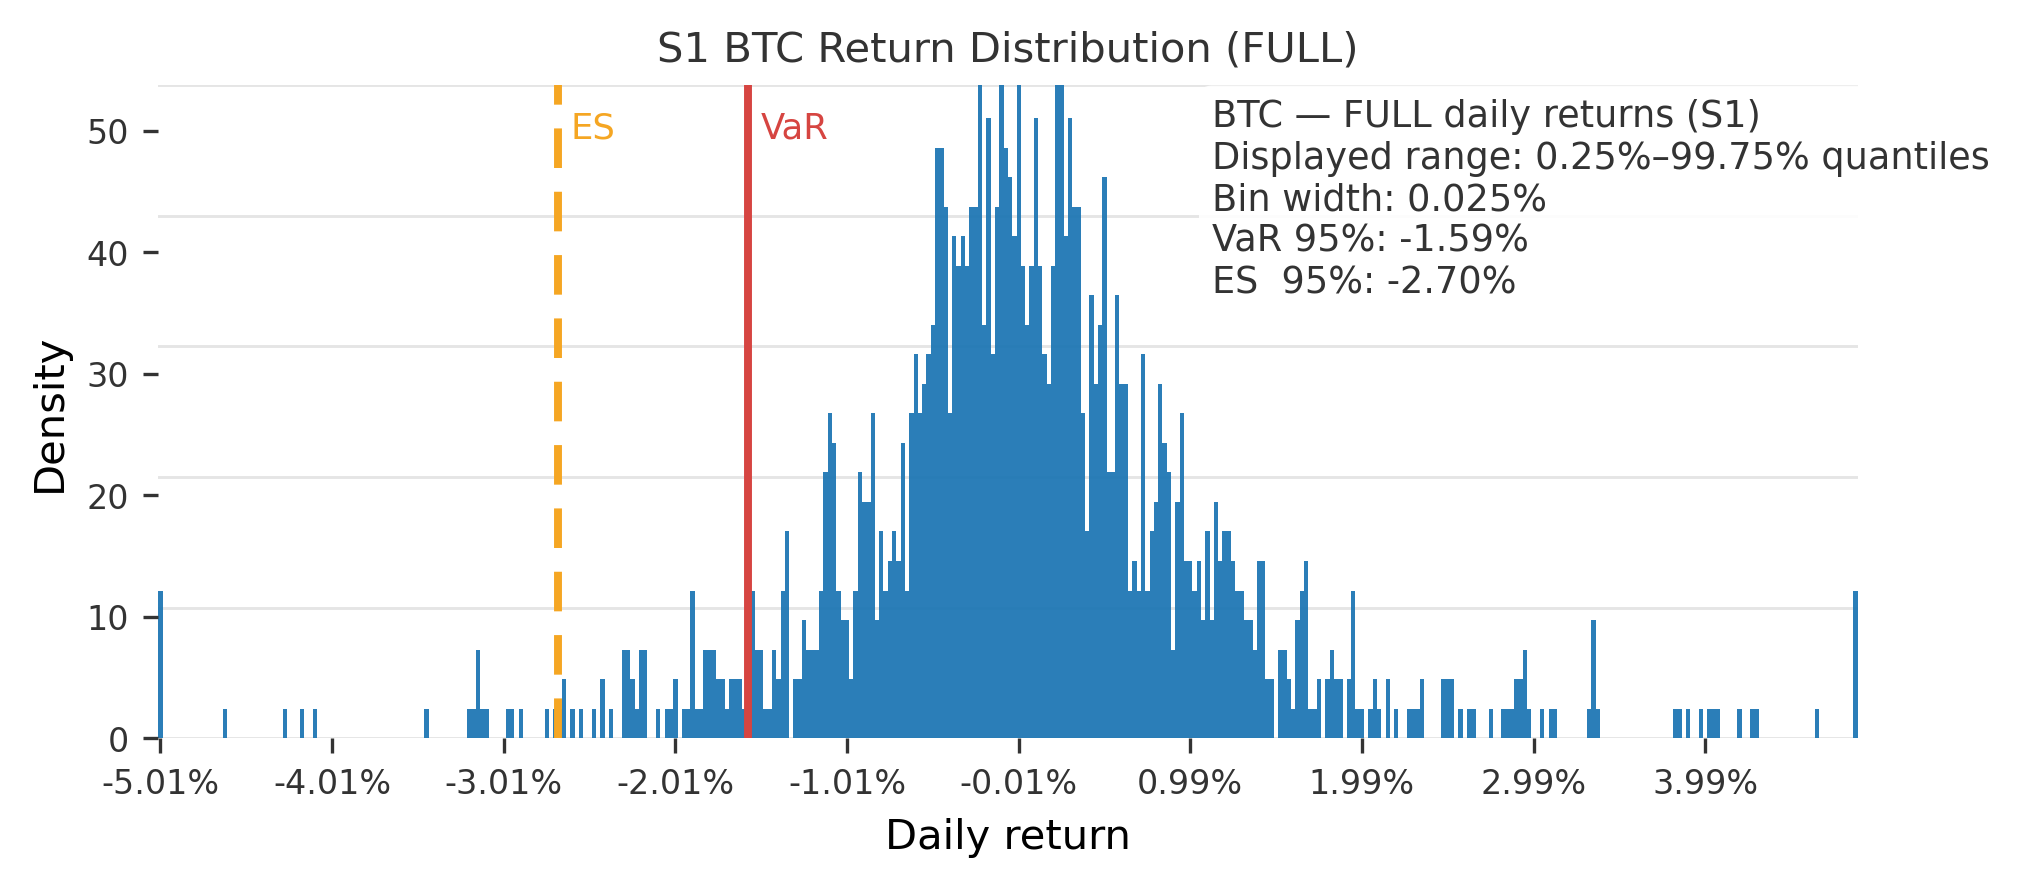

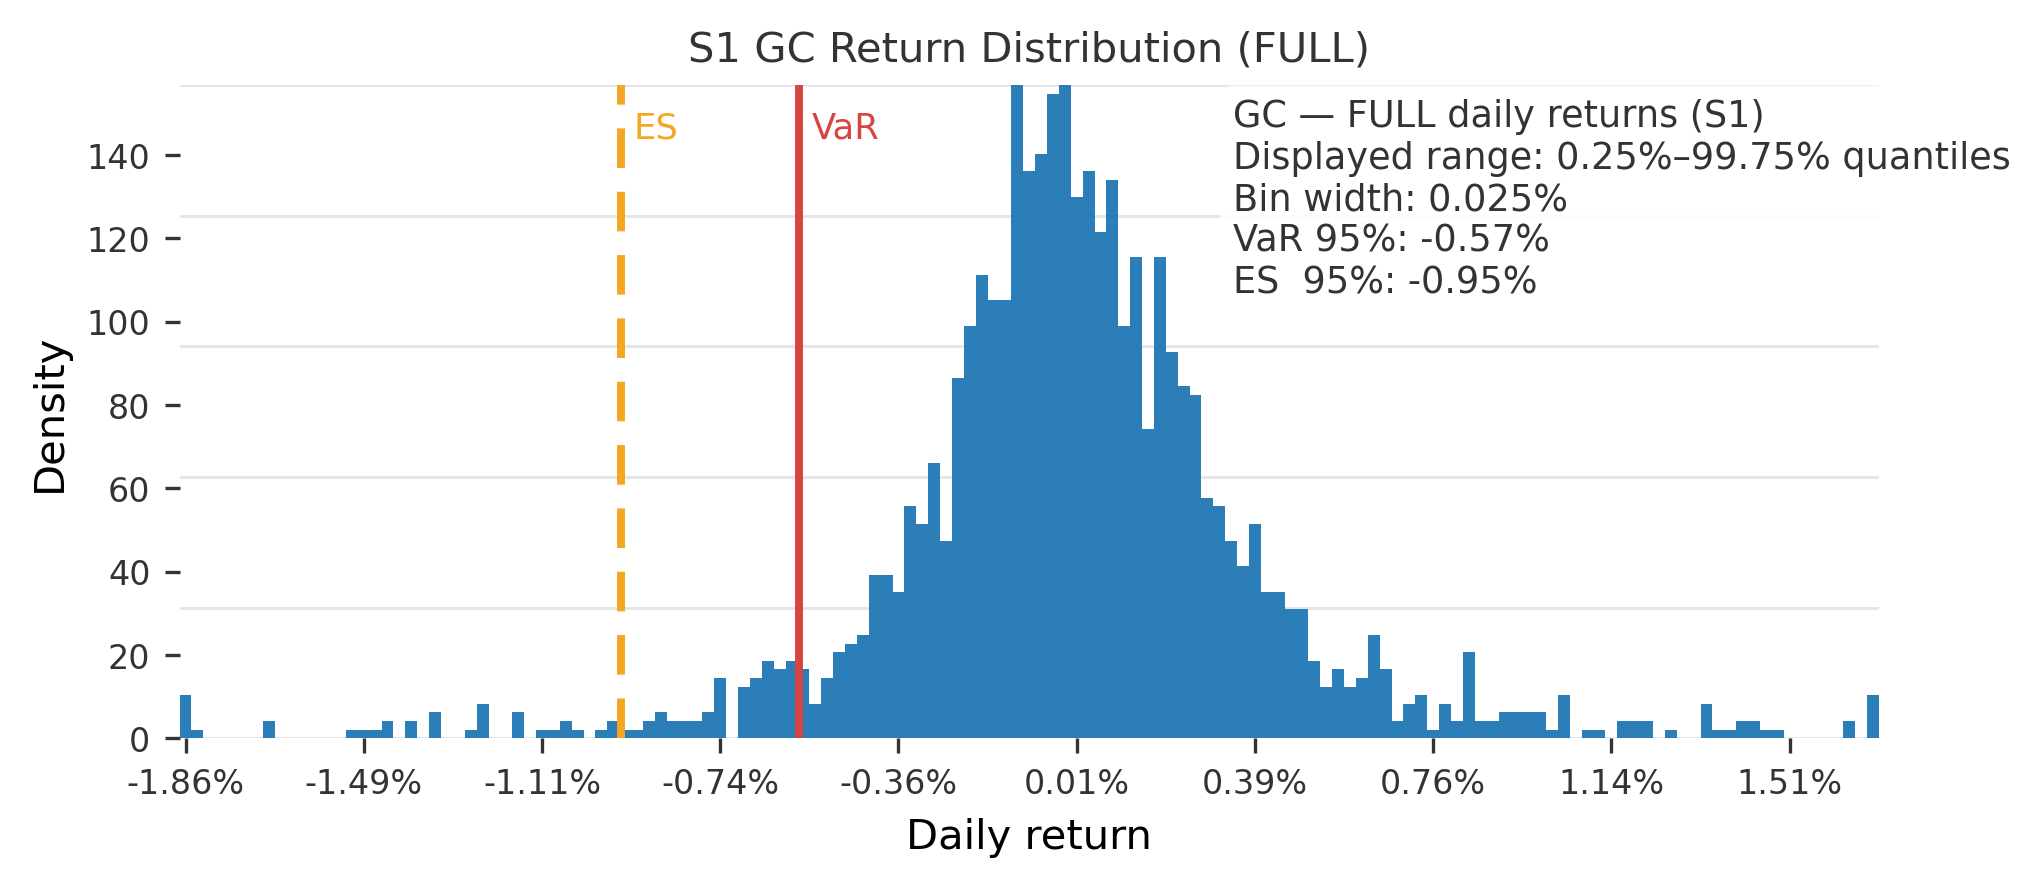

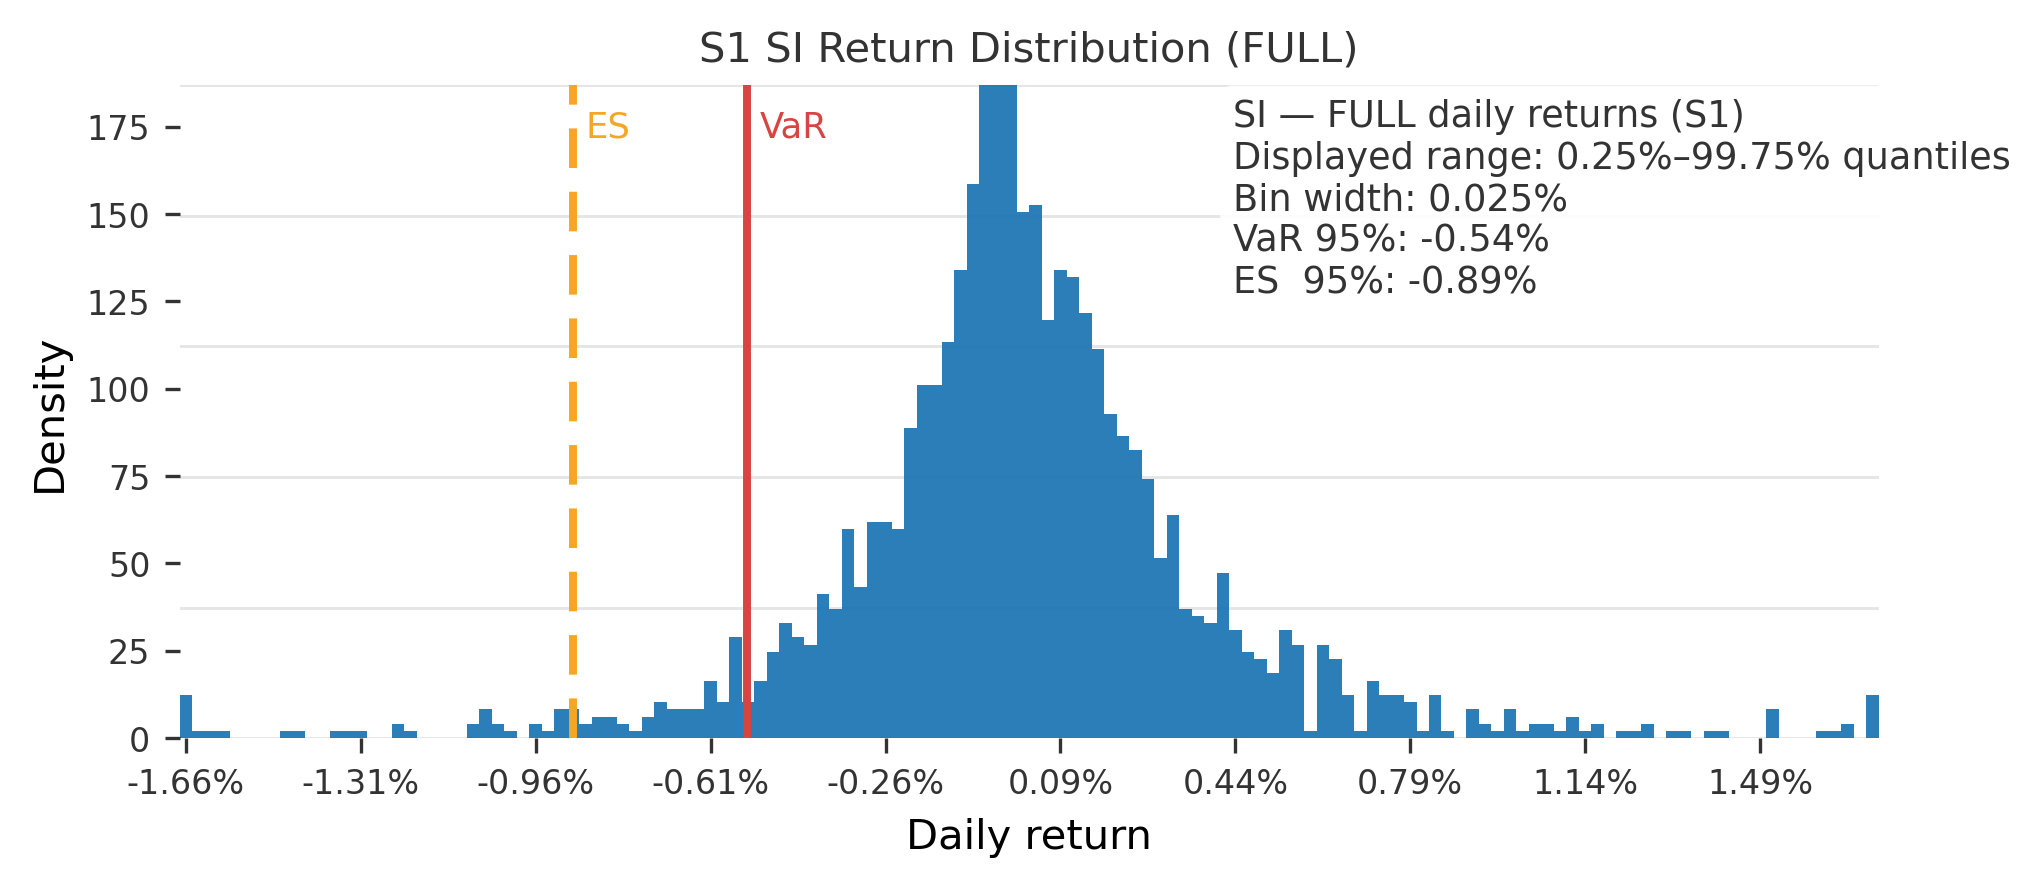

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ANNUAL_DAYS = 252

def _is_oos_mask(idx: pd.DatetimeIndex, is_end: pd.Timestamp):
    is_mask  = idx <= is_end
    oos_mask = idx >  is_end
    return is_mask, oos_mask

def _var_es(rets: pd.Series, alpha: float = 0.05):
    r = rets.dropna().astype(float)
    if r.empty:
        return np.nan, np.nan
    var = float(np.quantile(r, alpha))
    tail = r[r <= var]
    es = float(tail.mean()) if len(tail) > 0 else var
    return var, es

def _winsor_clip(r: pd.Series, lo_q: float, hi_q: float) -> pd.Series:
    """Clip returns to [q_lo, q_hi] for nicer histograms (does NOT change VaR/ES calc)."""
    if r.empty:
        return r
    lo = float(np.quantile(r, lo_q))
    hi = float(np.quantile(r, hi_q))
    return r.clip(lower=lo, upper=hi)

def _format_pct(x: float) -> str:
    if not np.isfinite(x):
        return ""
    return f"{x*100:.2f}%"

def _x_to_axes_frac(x: float, left: float, right: float) -> float:
    """Map an x-value to axes fraction [0,1] given current x-limits."""
    if not np.isfinite(x) or right <= left:
        return 0.5
    return float((x - left) / (right - left))

def plot_s1_return_distributions_var_es_granular(
    btc_eq: pd.Series, gc_eq: pd.Series, si_eq: pd.Series,
    is_end: str | pd.Timestamp = "2022-12-31",
    alpha: float = 0.05,
    period: str = "FULL",                    # "IS" | "OOS" | "FULL"

    view_clip=(0.0025, 0.9975),              
    bin_width=0.00025,                      
    density=True,
    ylim_cap_quantile=0.98,                  

    figsize=(6.4, 3.4),
):
    """
    Granular histogram per asset (S1):
      - fixed bin width
      - display x-range clipped to central mass (quantile clip)
      - y-axis capped to avoid one spike dominating
      - VaR/ES computed on full (unclipped) returns
      - VaR/ES lines + labels use distinct colours
      - annotation block auto-placed to avoid overlapping VaR/ES markers
    """
    is_end = pd.Timestamp(is_end)

    assets = [
        ("BTC", btc_eq, "#003B70"),
        ("GC",  gc_eq,  "#4F81BD"),
        ("SI",  si_eq,  "#A6A6A6"),
    ]

    DARK  = "#333333"
    LIGHT = "#E5E5E5"

    # distinct colours for risk markers
    C_VAR = "#D64541"
    C_ES  = "#F5A623"

    for name, eq_series, _asset_color in assets:
        eq = eq_series.astype(float).dropna()
        rets = eq.pct_change().dropna()
        if rets.empty:
            print(f"[{name}] no returns, skipping.")
            continue

        is_mask, oos_mask = _is_oos_mask(rets.index, is_end)

        if period.upper() == "IS":
            r_full = rets.loc[is_mask].dropna()
            tag = "IS"
        elif period.upper() == "OOS":
            r_full = rets.loc[oos_mask].dropna()
            tag = "OOS"
        else:
            r_full = rets.dropna()
            tag = "FULL"

        if r_full.empty:
            print(f"[{name}] {tag} empty, skipping.")
            continue

        var, es = _var_es(r_full, alpha=alpha)

        lo_q, hi_q = view_clip
        r_view = _winsor_clip(r_full, lo_q, hi_q)

        x_min = float(r_view.min())
        x_max = float(r_view.max())
        left  = bin_width * np.floor(x_min / bin_width)
        right = bin_width * np.ceil(x_max / bin_width)
        if right <= left:
            right = left + bin_width

        bins = np.arange(left, right + 1e-12, bin_width)

        fig, ax = plt.subplots(figsize=figsize, dpi=300)

        # compute heights so we can cap ylim
        counts, edges = np.histogram(r_view.values, bins=bins, density=density)
        centers = 0.5 * (edges[:-1] + edges[1:])
        widths = np.diff(edges)

        ax.bar(centers, counts, width=widths, align="center", alpha=0.95)

        # VaR / ES lines (distinct colours)
        ax.axvline(var, color=C_VAR, linewidth=1.9, linestyle="-", zorder=5)
        ax.axvline(es,  color=C_ES,  linewidth=1.9, linestyle=(0, (5, 3)), zorder=5)

        ax.set_xlim(left, right)
        target_ticks = 10
        step = max(1, int(np.ceil(len(centers) / target_ticks)))
        xt = centers[::step]
        ax.set_xticks(xt)
        ax.set_xticklabels([f"{v*100:.2f}%" for v in xt])

        if len(counts) > 0 and np.isfinite(counts).all():
            cap = float(np.quantile(counts, ylim_cap_quantile))
            if cap > 0:
                ax.set_ylim(0, cap * 1.10)

        y0, y1 = ax.get_ylim()
        for y in np.linspace(y0, y1, 6):
            ax.axhline(y, color=LIGHT, linewidth=0.7, zorder=0)

        y_top = ax.get_ylim()[1]
        ax.annotate("VaR", xy=(var, y_top), xytext=(3, -6), textcoords="offset points",
                    ha="left", va="top", fontsize=8.5, color=C_VAR, zorder=6)
        ax.annotate("ES",  xy=(es,  y_top), xytext=(3, -6), textcoords="offset points",
                    ha="left", va="top", fontsize=8.5, color=C_ES, zorder=6)

        var_f = _x_to_axes_frac(var, left, right)
        es_f  = _x_to_axes_frac(es,  left, right)
        m_f   = np.nanmean([var_f, es_f])
        text_x = 0.62 if m_f < 0.50 else 0.02

        txt = (
            f"{name} — {tag} daily returns (S1)\n"
            f"Displayed range: {lo_q:.2%}–{hi_q:.2%} quantiles\n"
            f"Bin width: {bin_width*100:.3f}%\n"
            f"VaR {int((1-alpha)*100)}%: {_format_pct(var)}\n"
            f"ES  {int((1-alpha)*100)}%: {_format_pct(es)}"
        )
        ax.text(
            text_x, 0.98, txt, transform=ax.transAxes,
            ha="left", va="top", fontsize=8.8, color=DARK, zorder=10,
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="none", alpha=0.92)
        )

        ax.set_title(f"S1 {name} Return Distribution ({tag})", fontsize=10, color=DARK, pad=6)
        ax.set_xlabel("Daily return")
        ax.set_ylabel("Density" if density else "Count")
        ax.tick_params(axis="both", colors=DARK, labelsize=8)
        for spine in ax.spines.values():
            spine.set_visible(False)

        fig.subplots_adjust(left=0.10, right=0.985, top=0.86, bottom=0.22)
        plt.show()



# have a few options here

plot_s1_return_distributions_var_es_granular(eq_btc_full, eq_gc_full, eq_si_full, period="FULL")
# plot_s1_return_distributions_var_es_granular(eq_btc_full, eq_gc_full, eq_si_full, period="IS")
# plot_s1_return_distributions_var_es_granular(eq_btc_full, eq_gc_full, eq_si_full, period="OOS")


## Extra visualisations for PPT & Report

Selected BTC pure-contango curve dates:
  poor: 2021-05-06, belly richness = -0.70 % p.a.
  normal: 2020-03-04, belly richness = 1.13 % p.a.
  rich: 2023-07-21, belly richness = 3.86 % p.a.


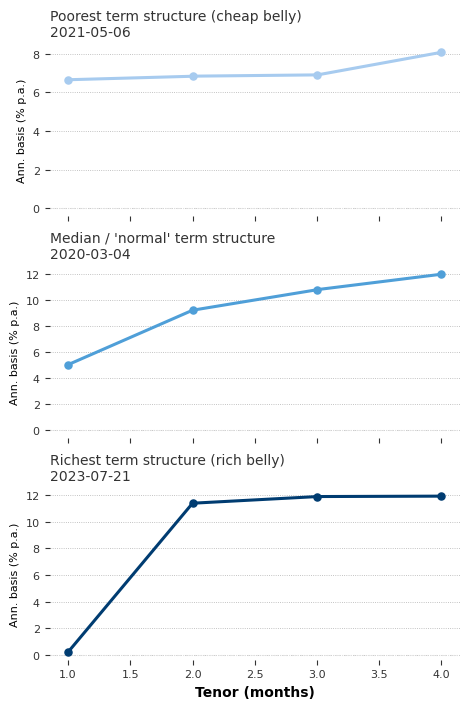

In [16]:
# 16. BTC term structure curves (pure contango filter)

COLUMBIA_DARK   = "#003C71"
COLUMBIA_MEDIUM = "#4F9FD8"
COLUMBIA_LIGHT  = "#A7CBEF"
LIGHT_GREY      = "#E0E0E0"
DARK_GREY       = "#333333"

cols   = ["btc1_basis_ann_pct", "btc2_basis_ann_pct", "btc3_basis_ann_pct", "btc4_basis_ann_pct"]
tenors = np.array([1, 2, 3, 4], dtype=float)

btc_curves = btc_basis_ann[cols].dropna().copy()

level_mask = (btc_curves >= 0) & (btc_curves < 100)
level_mask = level_mask.all(axis=1)

shape_mask = (
    (btc_curves["btc1_basis_ann_pct"] < btc_curves["btc2_basis_ann_pct"]) &
    (btc_curves["btc2_basis_ann_pct"] < btc_curves["btc3_basis_ann_pct"]) &
    (btc_curves["btc3_basis_ann_pct"] < btc_curves["btc4_basis_ann_pct"])
)

btc_curves_ctg = btc_curves[level_mask & shape_mask].copy()
if btc_curves_ctg.empty:
    raise ValueError("No suitable pure-contango BTC days found.")

b1 = btc_curves_ctg["btc1_basis_ann_pct"]
b3 = btc_curves_ctg["btc3_basis_ann_pct"]
b4 = btc_curves_ctg["btc4_basis_ann_pct"]

b3_line        = b1 + (b4 - b1) * (2/3)
belly_richness = b3 - b3_line

idx_rich   = belly_richness.idxmax()
idx_poor   = belly_richness.idxmin()
med_val    = belly_richness.median()
idx_normal = (belly_richness - med_val).abs().idxmin()

dates = {"poor": idx_poor, "normal": idx_normal, "rich": idx_rich}

print("Selected BTC pure-contango curve dates:")
for k, d in dates.items():
    print(f"  {k}: {d.date()}, belly richness = {belly_richness.loc[d]:.2f} % p.a.")

def smooth_curve(y_points: np.ndarray, tenors_base: np.ndarray, n_points: int = 200):
    t_smooth = np.linspace(tenors_base.min(), tenors_base.max(), n_points)
    y_smooth = np.interp(t_smooth, tenors_base, y_points)
    return t_smooth, y_smooth

POOR_COLOR   = COLUMBIA_LIGHT
NORMAL_COLOR = COLUMBIA_MEDIUM
RICH_COLOR   = COLUMBIA_DARK

fig, axes = plt.subplots(3, 1, figsize=(4.8, 7.2), sharex=True)

panel_cfg = [
    ("Poorest term structure (cheap belly)",  "poor",   POOR_COLOR),
    ("Median / 'normal' term structure",      "normal", NORMAL_COLOR),
    ("Richest term structure (rich belly)",   "rich",   RICH_COLOR),
]

for ax, (title, key, color) in zip(axes, panel_cfg):
    d = dates[key]
    y = btc_curves_ctg.loc[d, cols].values.astype(float)
    t_s, y_s = smooth_curve(y, tenors)

    ax.plot(t_s, y_s, color=color, linewidth=2.2)
    ax.scatter(tenors, y, color=color, s=26, zorder=3)

    ax.axhline(0, color=LIGHT_GREY, linestyle=":", linewidth=0.8)
    ax.set_ylabel("Ann. basis (% p.a.)", fontsize=8)
    ax.set_title(f"{title}\n{d.date()}", fontsize=10, color=DARK_GREY, loc="left")

    ax.yaxis.grid(True, linestyle=":", linewidth=0.6)
    ax.xaxis.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="both", colors=DARK_GREY, labelsize=8)

axes[-1].set_xlabel("Tenor (months)", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


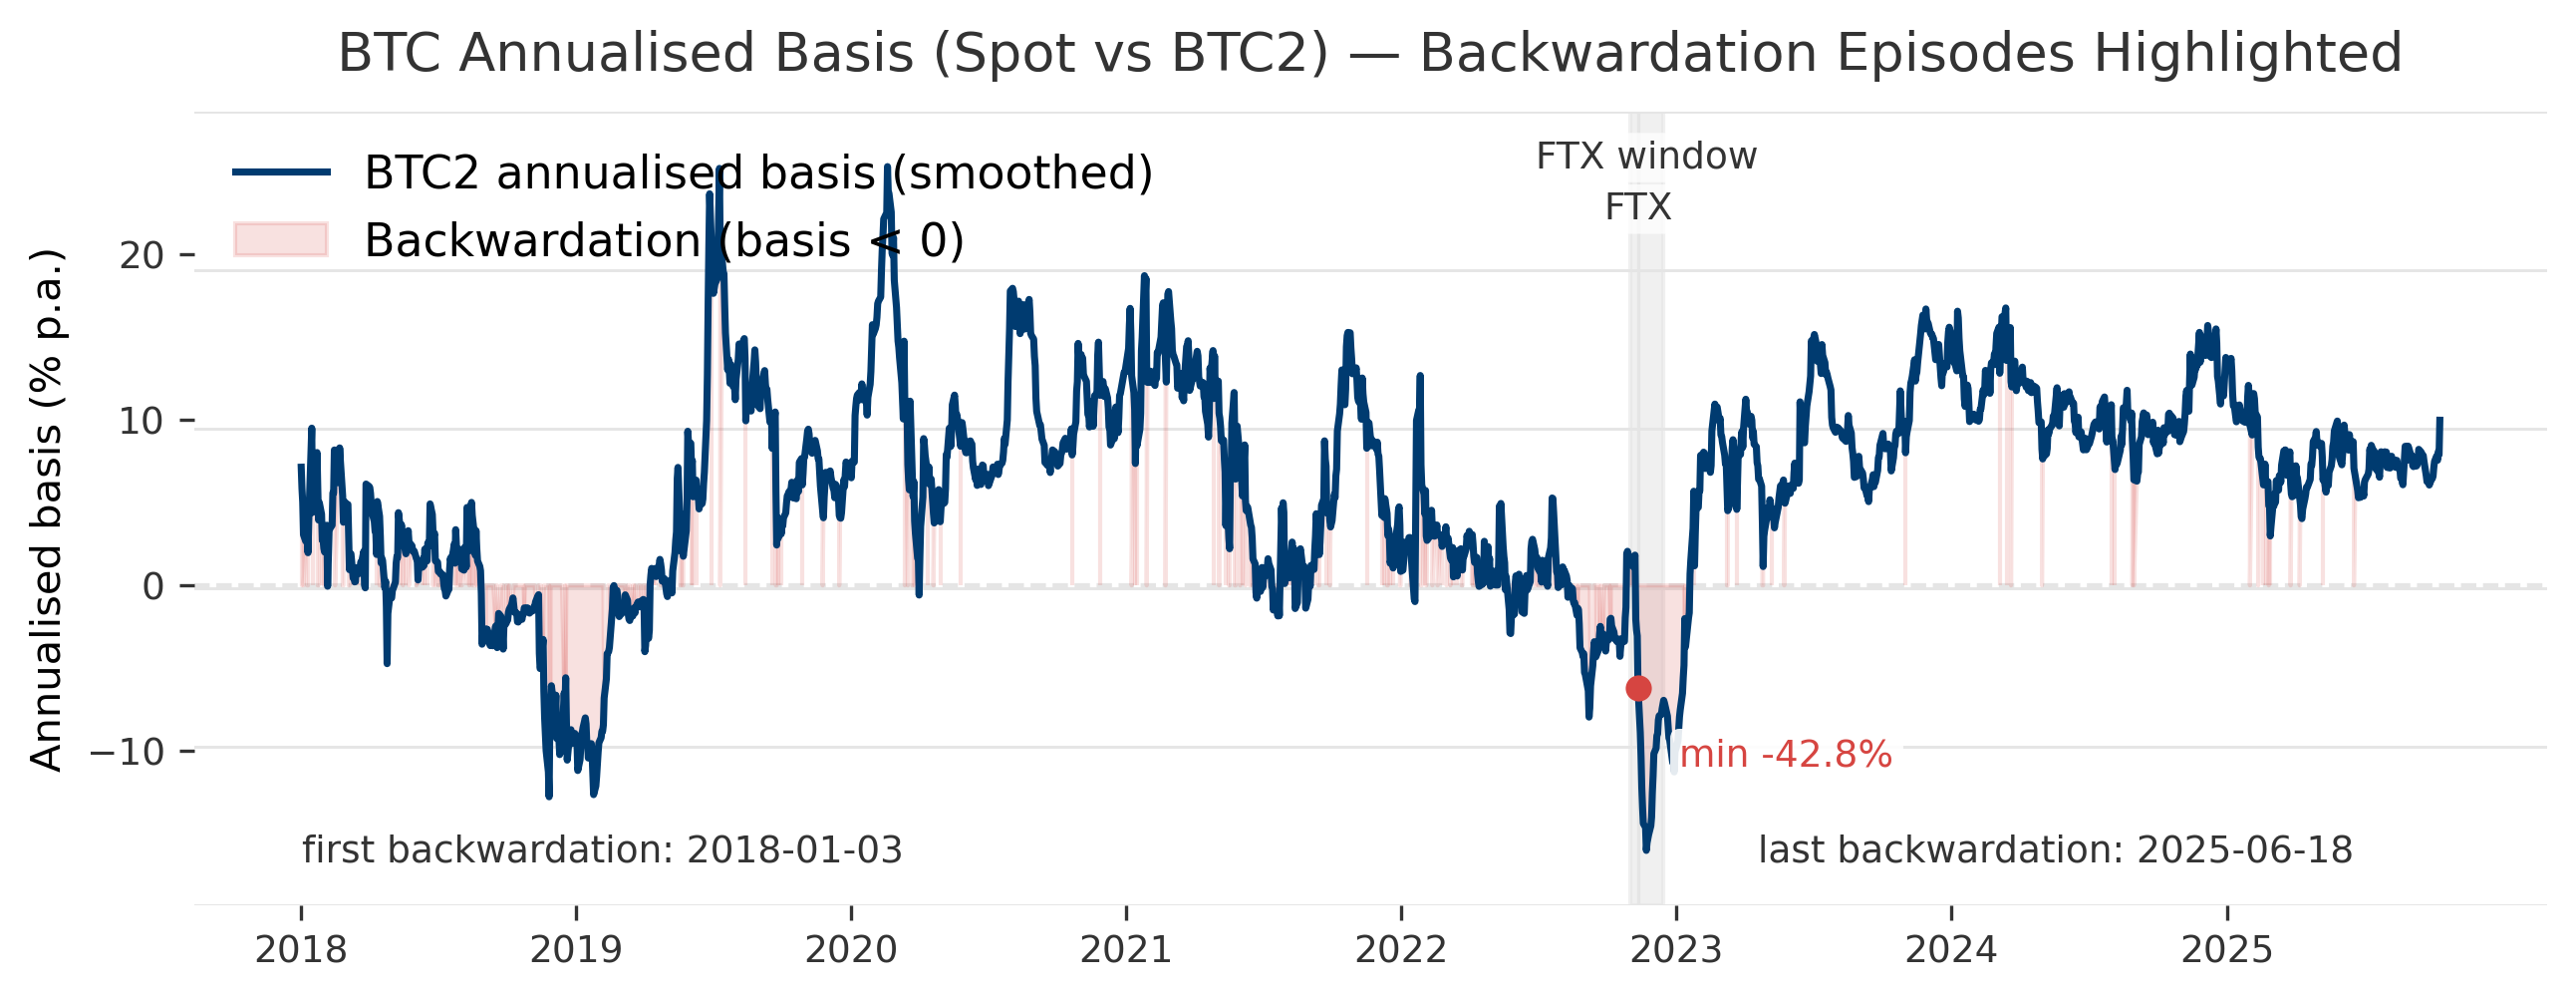

In [17]:
# BTC annualised basis (2018 to latest) + backwardation flags (FTX)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DARK  = "#333333"
LIGHT = "#E5E5E5"
C_BTC = "#003B70"
C_NEG = "#D64541"   

def _compute_ann_basis_from_prices(
    df_btc: pd.DataFrame,
    btc_dte: pd.DataFrame,
    fut: str = "btc2",
    spot: str = "xbt_usd",
    days_in_year: float = 365.0,
) -> pd.Series:
    """Annualised basis (decimal): (F - S)/S * (365 / DTE)."""
    fut_dte = f"{fut}_DTE"
    panel = (
        df_btc[[spot, fut]]
        .join(btc_dte[[fut_dte]], how="inner")
        .dropna()
        .copy()
    )
    dte = panel[fut_dte].clip(lower=1).astype(float)
    S = panel[spot].astype(float)
    F = panel[fut].astype(float)
    ann = ((F - S) / S) * (days_in_year / dte)
    ann.name = f"{fut}_ann_basis"
    return ann

def _clip_for_display_keep_zero(
    s: pd.Series,
    lo_q: float = 0.005,
    hi_q: float = 0.995,
) -> pd.Series:
    """Quantile-clip for DISPLAY only. Ensures 0 is inside range."""
    x = s.dropna().astype(float)
    if x.empty:
        return s
    lo = float(np.quantile(x, lo_q))
    hi = float(np.quantile(x, hi_q))
    lo = min(lo, 0.0)
    hi = max(hi, 0.0)
    if hi <= lo:
        hi = lo + 1e-6
    return s.clip(lower=lo, upper=hi)

def _smooth_for_display(
    s: pd.Series,
    method: str = "ewm",          # "ewm" | "rolling_mean" | "rolling_median" - can choose between these 3
    span: int = 12,               # for ewm
    window: int = 9,              
) -> pd.Series:
    """Smoothing for DISPLAY only (keeps index)."""
    x = s.astype(float)
    m = method.lower()
    if m == "ewm":
        return x.ewm(span=span, adjust=False, min_periods=1).mean()
    if m == "rolling_mean":
        return x.rolling(window=window, min_periods=1).mean()
    if m == "rolling_median":
        return x.rolling(window=window, min_periods=1).median()
    return x

def plot_btc_ann_basis_with_backwardation(
    df_btc: pd.DataFrame,
    btc_dte: pd.DataFrame,
    btc_basis_ann: pd.DataFrame | None = None,
    tenor: str = "btc2",
    start: str | pd.Timestamp = "2018-01-01",
    end: str | pd.Timestamp | None = None,
    ftx_window=("2022-11-01", "2022-12-15"),
    ftx_line="2022-11-11",
    title="BTC Annualised Basis (Spot vs Futures)",
    out_png="btc_annualised_basis_backwardation.png",
    out_pdf="btc_annualised_basis_backwardation.pdf",
    figsize=(8.6, 3.9),

    display_clip_q=(0.005, 0.995),     # Remove the extremes
    smooth_method="ewm",               
    smooth_span=12,                    # ~2.5 weeks (trading days)
    smooth_window=9,                   
):
    start = pd.Timestamp(start)
    end = pd.Timestamp(end) if end is not None else None

    ann_raw = None
    if btc_basis_ann is not None:
        col_pct = f"{tenor}_basis_ann_pct"
        if col_pct in btc_basis_ann.columns:
            ann_raw = (btc_basis_ann[col_pct].astype(float) / 100.0).rename(f"{tenor}_ann_basis")

    if ann_raw is None:
        ann_raw = _compute_ann_basis_from_prices(df_btc, btc_dte, fut=tenor)

    ann_raw = ann_raw.dropna().sort_index()
    if end is None:
        end = ann_raw.index.max()
    ann_raw = ann_raw.loc[start:end].copy()
    if ann_raw.empty:
        raise ValueError("Annualised basis series is empty after date filtering.")

    # Backwardation detection / dates based on RAW series
    neg = ann_raw < 0
    neg_any = bool(neg.any())

    lo_q, hi_q = display_clip_q
    ann_disp = _clip_for_display_keep_zero(ann_raw, lo_q=lo_q, hi_q=hi_q)
    ann_plot = _smooth_for_display(
        ann_disp,
        method=smooth_method,
        span=smooth_span,
        window=smooth_window,
    )

    fig, ax = plt.subplots(figsize=figsize, dpi=300)


    w0, w1 = pd.Timestamp(ftx_window[0]), pd.Timestamp(ftx_window[1])
    if ann_plot.index.min() <= w1 and ann_plot.index.max() >= w0:
        ax.axvspan(w0, w1, color=LIGHT, alpha=0.55, zorder=0)
        w_mid = w0 + (w1 - w0) / 2
        ax.text(
            w_mid, 0.965, "FTX window",
            transform=ax.get_xaxis_transform(),
            ha="center", va="top",
            fontsize=9, color=DARK,
            bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="none", alpha=0.75),
            zorder=3,
        )

    ftx_dt = pd.Timestamp(ftx_line)
    if ann_plot.index.min() <= ftx_dt <= ann_plot.index.max():
        ax.axvline(ftx_dt, color=LIGHT, linewidth=0.8, zorder=1)
        ax.text(
            ftx_dt, 0.90, "FTX",
            transform=ax.get_xaxis_transform(),
            ha="center", va="top",
            fontsize=9, color=DARK,
            bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="none", alpha=0.75),
            zorder=3,
        )

    # Main line is smoothed:
    ax.plot(
        ann_plot.index,
        ann_plot.values * 100.0,
        color=C_BTC,
        linewidth=1.7,
        label=f"{tenor.upper()} annualised basis (smoothed)",
        zorder=2,
    )

    # 0 line
    ax.axhline(0, color=LIGHT, linestyle="--", linewidth=1.0, zorder=0)

    y_min = float(np.nanmin(ann_plot.values * 100.0))
    y_max = float(np.nanmax(ann_plot.values * 100.0))
    pad = 0.08 * (y_max - y_min) if y_max > y_min else 1.0
    ax.set_ylim(y_min - pad, y_max + pad)

    if neg_any:
        mask = neg.reindex(ann_plot.index, fill_value=False).values
        y_plot = ann_plot.values * 100.0

        ax.fill_between(
            ann_plot.index,
            y_plot,
            0.0,
            where=mask,
            color=C_NEG,
            alpha=0.16,
            interpolate=True,
            label="Backwardation (basis < 0)",
            zorder=1,
        )

        first_neg = ann_raw.index[np.where(neg.values)[0][0]]
        last_neg  = ann_raw.index[np.where(neg.values)[0][-1]]
        min_dt_raw  = ann_raw.idxmin()
        min_val_raw = float(ann_raw.loc[min_dt_raw] * 100.0)

        if min_dt_raw in ann_plot.index:
            min_val_plot = float(ann_plot.loc[min_dt_raw] * 100.0)
        else:
            near_dt = ann_plot.index[ann_plot.index.get_indexer([min_dt_raw], method="nearest")[0]]
            min_val_plot = float(ann_plot.loc[near_dt] * 100.0)
            min_dt_raw = near_dt  

        ax.scatter([min_dt_raw], [min_val_plot], color=C_NEG, s=28, zorder=5)

        y0, y1 = ax.get_ylim()
        span = (y1 - y0) if np.isfinite(y1 - y0) and (y1 > y0) else 1.0
        place_above = (min_val_plot - y0) < 0.20 * span
        dy = 12 if place_above else -12
        va = "bottom" if place_above else "top"

        ax.annotate(
            f"min {min_val_raw:.1f}%",
            xy=(min_dt_raw, min_val_plot),
            xytext=(10, dy),
            textcoords="offset points",
            ha="left", va=va,
            fontsize=9,
            color=C_NEG,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="none", alpha=0.90),
            zorder=6,
        )

        ax.text(
            first_neg, 0.045, f"first backwardation: {first_neg.date()}",
            transform=ax.get_xaxis_transform(),
            ha="left", va="bottom",
            fontsize=9, color=DARK,
            bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="none", alpha=0.70),
            zorder=4,
        )
        ax.text(
            last_neg, 0.045, f"last backwardation: {last_neg.date()}",
            transform=ax.get_xaxis_transform(),
            ha="right", va="bottom",
            fontsize=9, color=DARK,
            bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="none", alpha=0.70),
            zorder=4,
        )
    else:
        ax.text(
            ann_plot.index[0], 0.045, "No backwardation observed (basis never < 0).",
            transform=ax.get_xaxis_transform(),
            ha="left", va="bottom",
            fontsize=9, color=DARK,
            bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="none", alpha=0.70),
            zorder=4,
        )

    # Others, labels, legend
    ax.set_title(title, fontsize=13, color=DARK, pad=10)
    ax.set_ylabel("Annualised basis (% p.a.)")
    ax.set_xlabel("")
    ax.tick_params(axis="both", colors=DARK, labelsize=9)
    for spine in ax.spines.values():
        spine.set_visible(False)

    years = sorted({d.year for d in ann_plot.index})
    year_ticks = [pd.Timestamp(year=y, month=1, day=1) for y in years]
    ax.set_xticks(year_ticks)
    ax.set_xticklabels([str(y.year) for y in year_ticks])

    y0, y1 = ax.get_ylim()
    for y in np.linspace(y0, y1, 6):
        ax.axhline(y, color=LIGHT, linewidth=0.7, zorder=0)

    ax.legend(loc="upper left", frameon=False, fontsize=11)
    fig.subplots_adjust(left=0.075, right=0.99, top=0.88, bottom=0.20)

    fig.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(out_pdf, bbox_inches="tight", pad_inches=0.02)
    plt.show()

    return ann_raw

ann_btc2_raw = plot_btc_ann_basis_with_backwardation(
    df_btc=df_btc,
    btc_dte=btc_dte,
    btc_basis_ann=btc_basis_ann,
    tenor="btc2",
    start="2018-01-01",
    end=None,
    ftx_window=("2022-11-01", "2022-12-15"),
    ftx_line="2022-11-11",
    title="BTC Annualised Basis (Spot vs BTC2) — Backwardation Episodes Highlighted",
    display_clip_q=(0.005, 0.995),
    smooth_method="ewm",
    smooth_span=12,     
)


/var/folders/tl/hb3sh0p16wb8f6cdsnkjq_wm0000gn/T/ipykernel_89465/669719521.py:70: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  bench_rets = bench_px.pct_change().dropna(how="all")



=== S1 vs major asset classes — correlation (daily returns), 2018–2025 ===
        Gold (GLD)  Credit (HYG)  US Eq (QQQ)  US Eq (SPY)  US Rates (TLT)  Oil (USO)  USD (UUP)  Real Estate (VNQ)  VIX (^VIX)
S1 BTC      -0.006         0.011       -0.034       -0.015           0.021     -0.019      0.050              0.024       0.036
S1 GC        0.059         0.006       -0.004       -0.013           0.111      0.002     -0.094             -0.029      -0.041
S1 SI        0.025         0.073        0.106        0.098           0.043      0.012     -0.053              0.061      -0.130


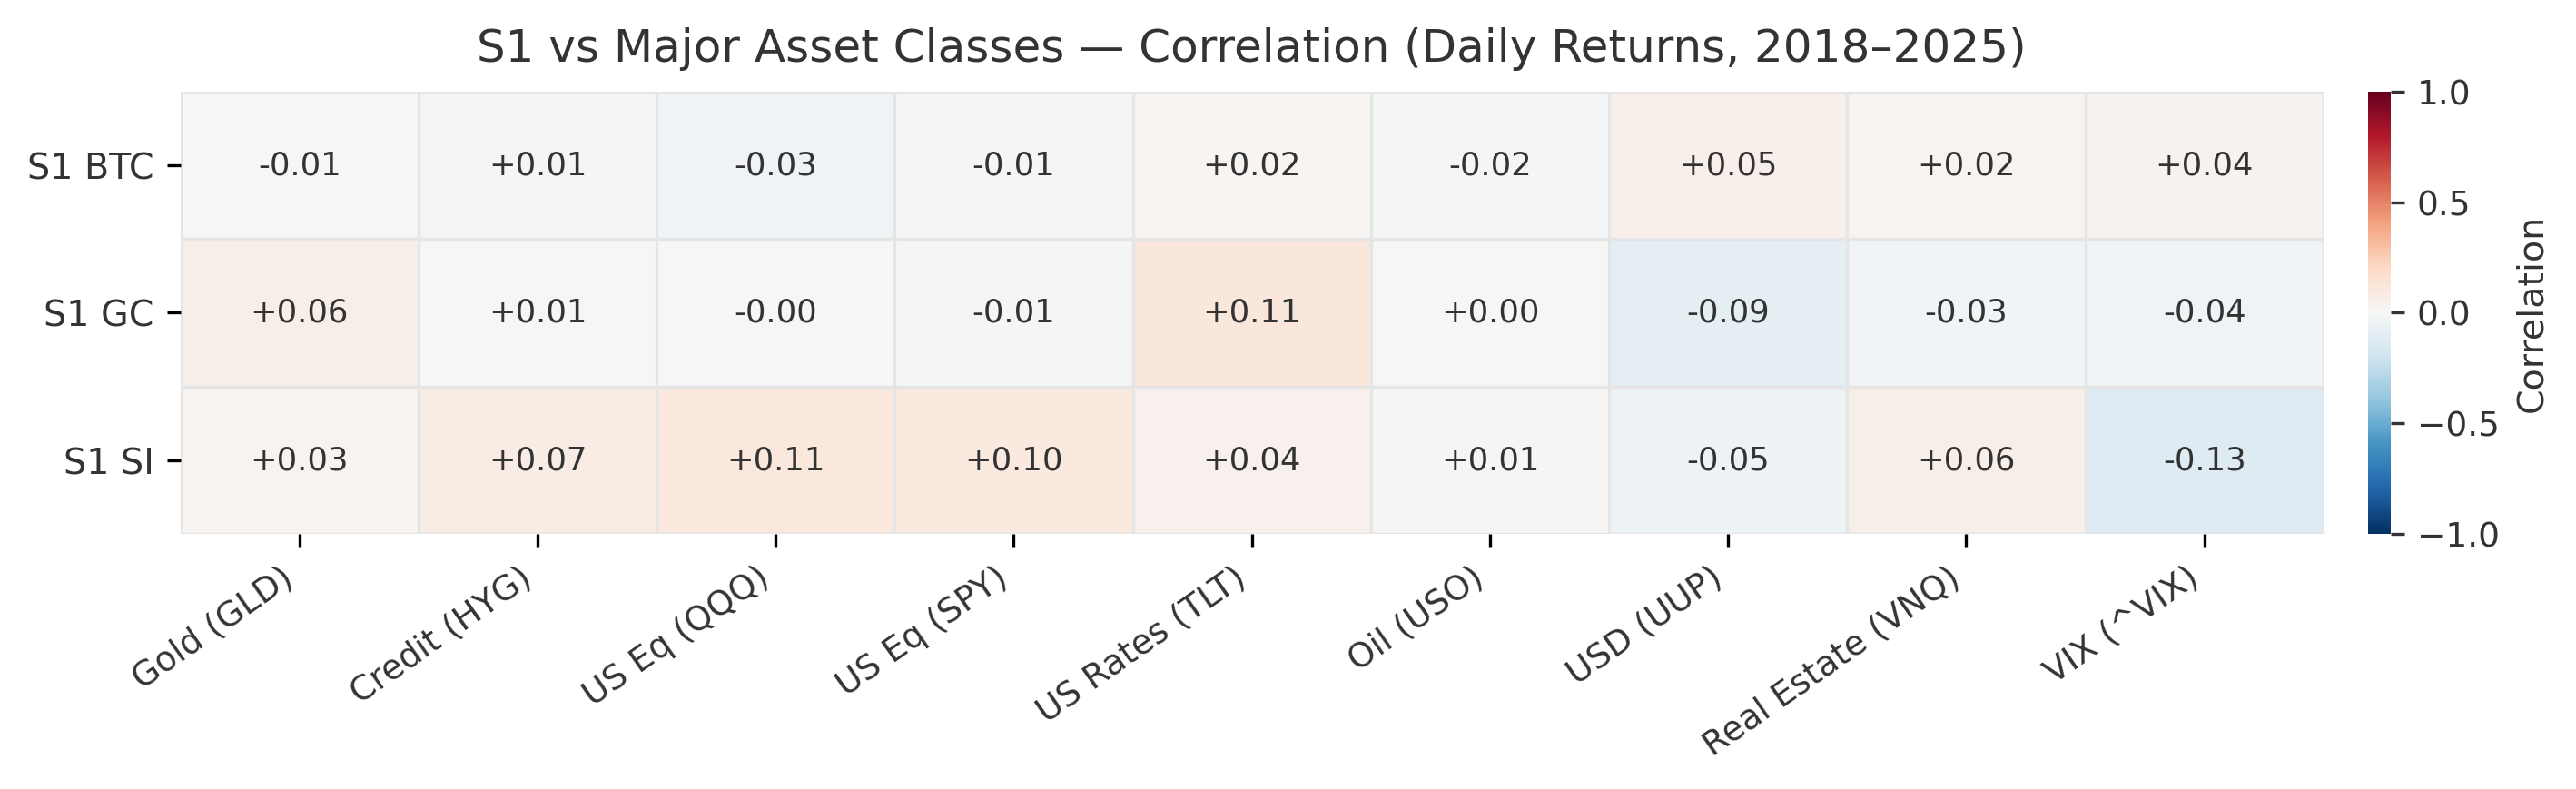

(<Figure size 2940x870 with 2 Axes>,
 <Axes: title={'center': 'S1 vs Major Asset Classes — Correlation (Daily Returns, 2018–2025)'}>)

In [18]:
# S1 correlation heatmap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import yfinance as yf
except ImportError as e:
    raise ImportError("yfinance not installed. Run: pip install yfinance") from e

DARK  = "#333333"
LIGHT = "#E5E5E5"
C_BTC = "#003B70"

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.edgecolor"] = "none"

def _eq_to_rets(eq: pd.Series) -> pd.Series:
    eq = eq.dropna().astype(float).sort_index()
    return eq.pct_change().dropna()

def _yf_download_prices(
    tickers: dict[str, str],   # {"nice name": "YF_TICKER", ...}
    start: str,
    end: str,
) -> pd.DataFrame:
    tk = list(tickers.values())
    raw = yf.download(
        tickers=tk,
        start=start,
        end=end,
        interval="1d",
        auto_adjust=True,
        actions=False,
        progress=False,
        threads=True,
    )

    if isinstance(raw.columns, pd.MultiIndex):
        field = "Adj Close" if ("Adj Close" in raw.columns.get_level_values(0)) else "Close"
        px = raw[field].copy()
    else:
        px = raw.copy()

    inv = {v: k for k, v in tickers.items()}
    px = px.rename(columns=inv)

    px.index = pd.to_datetime(px.index)
    px = px.sort_index()
    px = px.dropna(axis=1, how="all")
    return px

def corr_matrix_s1_vs_benchmarks_full(
    s1_eq_map: dict[str, pd.Series],   # {"BTC": eq, "GC": eq, "SI": eq}
    bench_px: pd.DataFrame,            # benchmark prices
    start: str,
    end: str,
) -> pd.DataFrame:
    s1_rets = {}
    for k, eq in s1_eq_map.items():
        if eq is None or eq.dropna().empty:
            continue
        s1_rets[f"S1 {k}"] = _eq_to_rets(eq)

    s1_rets = pd.concat(s1_rets, axis=1).dropna(how="all")
    if s1_rets.empty:
        raise ValueError("No S1 returns available.")

    bench_rets = bench_px.pct_change().dropna(how="all")

    t0 = pd.Timestamp(start)
    t1 = pd.Timestamp(end)
    s1_rets = s1_rets.loc[(s1_rets.index >= t0) & (s1_rets.index <= t1)]
    bench_rets = bench_rets.loc[(bench_rets.index >= t0) & (bench_rets.index <= t1)]

    df = pd.concat([s1_rets, bench_rets], axis=1).dropna()
    if df.empty:
        raise ValueError("No overlapping dates after aligning S1 returns with benchmark returns.")

    strat_cols = list(s1_rets.columns)
    bench_cols = list(bench_rets.columns)

    out = pd.DataFrame(index=strat_cols, columns=bench_cols, dtype=float)
    for s in strat_cols:
        for b in bench_cols:
            out.loc[s, b] = df[s].corr(df[b])
    return out

def plot_corr_heatmap(
    corr: pd.DataFrame,
    title: str = "S1 vs Major Asset Classes — Correlation (Daily Returns)",
    out_png: str | None = "s1_corr_heatmap_2018_2025.png",
    out_pdf: str | None = "s1_corr_heatmap_2018_2025.pdf",
    figsize=(9.6, 2.9),
):
    mat = corr.astype(float)

    fig, ax = plt.subplots(figsize=figsize, dpi=300)

    im = ax.imshow(mat.values, vmin=-1, vmax=1, aspect="auto", cmap="RdBu_r")

    # Ticks/labels
    ax.set_xticks(np.arange(mat.shape[1]))
    ax.set_yticks(np.arange(mat.shape[0]))
    ax.set_xticklabels(mat.columns.tolist(), rotation=35, ha="right", fontsize=9, color=DARK)
    ax.set_yticklabels(mat.index.tolist(), fontsize=9.5, color=DARK)

    ax.set_title(title, fontsize=12, color=DARK, pad=8)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.iat[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=8.5, color=DARK)

    ax.set_xticks(np.arange(-0.5, mat.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, mat.shape[0], 1), minor=True)
    ax.grid(which="minor", color=LIGHT, linestyle="-", linewidth=0.8)
    ax.tick_params(which="minor", bottom=False, left=False)

    for spine in ax.spines.values():
        spine.set_visible(False)


    cbar = fig.colorbar(im, ax=ax, fraction=0.030, pad=0.02)
    cbar.ax.tick_params(labelsize=9, colors=DARK)
    cbar.set_label("Correlation", fontsize=9.5, color=DARK)

    fig.subplots_adjust(left=0.14, right=0.985, top=0.84, bottom=0.28)

    if out_png:
        fig.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.02)
    if out_pdf:
        fig.savefig(out_pdf, bbox_inches="tight", pad_inches=0.02)

    plt.show()
    return fig, ax


s1_eq_map = {
    "BTC": results_s1_btc["equity"],
    "GC":  results_s1_gc["equity"],
    "SI":  results_s1_si["equity"],
}


bench_tickers = {
    "US Eq (SPY)": "SPY",
    "US Eq (QQQ)": "QQQ",
    "US Rates (TLT)": "TLT",
    "Credit (HYG)": "HYG",
    "Gold (GLD)": "GLD",
    "Oil (USO)": "USO",
    "USD (UUP)": "UUP",
    "Real Estate (VNQ)": "VNQ",
    "VIX (^VIX)": "^VIX",
}

START = "2018-01-01"
END   = "2025-12-31"

bench_prices = _yf_download_prices(bench_tickers, start=START, end=END)

corr_full = corr_matrix_s1_vs_benchmarks_full(
    s1_eq_map=s1_eq_map,
    bench_px=bench_prices,
    start=START,
    end=END,
)

# Clean printed table (round + aligned)
print("\n=== S1 vs major asset classes — correlation (daily returns), 2018–2025 ===")
print(corr_full.round(3).to_string())

# Heatmap figure
plot_corr_heatmap(
    corr_full,
    title="S1 vs Major Asset Classes — Correlation (Daily Returns, 2018–2025)",
    out_png="s1_corr_heatmap_2018_2025.png",
    out_pdf="s1_corr_heatmap_2018_2025.pdf",
    figsize=(9.8, 2.9),
)
